<h1 style="color:red; text-align:center;">
C. ELEGANS SEGMENTATION USING TOPOLOGY-AWARE TRANSFER LEARNING
</h1>

## Overview

This experiment investigates whether the best topology-aware road segmentation model can be transferred to a biomedical segmentation task. The selected source model was **Road Model 5**, trained using:

**BCE + Dice + soft-clDice + SATLoss Creator**

The goal was to segment **C. elegans worm structures** from microscopy images while preserving their elongated shape and connectivity.

---

## Dataset Preparation

The BBBC010 C. elegans dataset contains grayscale microscopy images and binary foreground masks. A total of **96 matched image-mask pairs** were used.

Since the pretrained road model was trained on **96 × 96** patches, the C. elegans images were also divided into overlapping **96 × 96** patches using stride **48**.

The preprocessing steps were:

- Grayscale images were normalized to the range **[0, 1]**
- Each grayscale patch was repeated into **3 channels** to match the road model input
- Masks were converted to binary values: **0 = background**, **1 = worm foreground**
- Patches with sufficient foreground were kept, with a small number of background patches retained

A total of **6058 patches** were created:

| Split | Number of patches |
|---|---:|
| Training | 4222 |
| Validation | 878 |
| Testing | 958 |

---

## Transfer Learning Strategy

The pretrained road model was loaded and fine-tuned on the C. elegans patches. This allowed the model to reuse topology-aware features learned from road networks and adapt them to worm-like biological structures.

The fine-tuning loss was:

**Total Loss = BCE + Dice Loss + soft-clDice Loss**

where:

- **BCE** improves pixel-wise foreground/background classification
- **Dice Loss** improves overlap between prediction and ground truth
- **soft-clDice Loss** improves connectivity of thin structures

---

## SATLoss Fine-Tuning

After transfer learning, an additional SATLoss Creator fine-tuning stage was tested:

**Total Loss = BCE + Dice Loss + soft-clDice Loss + SATLoss Creator**

This stage was included to examine whether persistent-homology-based topology supervision could further improve C. elegans segmentation.

However, the best validation performance was already achieved before SATLoss fine-tuning. Therefore, the SATLoss stage did not improve the final saved test performance on this dataset.

---

## Final Results

| Model | Accuracy ↑ | Dice ↑ | clDice ↑ | β0 Error ↓ | β1 Error ↓ | Threshold |
|---|---:|---:|---:|---:|---:|---:|
| Road Model 5 before fine-tuning | 0.8960 | 0.1604 | - | - | - | 0.5000 |
| Transfer learning | **0.9539** | **0.7449** | **0.7727** | **0.3904** | **0.0950** | 0.5000 |
| Transfer learning + SATLoss Creator | **0.9539** | **0.7449** | **0.7727** | **0.3904** | **0.0950** | 0.5000 |

---

## Visual Analysis

The prediction results show that the transferred model successfully segmented the worm structures from microscopy images. The model preserved long curved worm bodies, thin structures, and connected foreground regions.

Most predictions followed the ground-truth masks closely, especially for clear and elongated worm regions. Some small errors appeared near noisy backgrounds, faint boundaries, and patch borders, which is expected in microscopy segmentation.

---

## Key Observations

- The topology-aware road model transferred successfully to C. elegans segmentation.
- Fine-tuning was essential because road images and microscopy images have very different appearances.
- Dice improved from **0.1604 before fine-tuning** to **0.7449 after fine-tuning**.
- clDice reached **0.7727**, showing good preservation of worm connectivity.
- Additional SATLoss Creator fine-tuning did not improve the final test results.
- This suggests that the hybrid transfer model already learned sufficient structural information for this smoother biological dataset.

---

## Conclusion

The experiment shows that topology-aware features learned from road segmentation can transfer effectively to biomedical microscopy segmentation. The best C. elegans result was obtained using transfer learning from **Road Model 5**, followed by fine-tuning with **BCE + Dice + soft-clDice**.

Although SATLoss was highly useful in the road segmentation experiment, its additional fine-tuning did not further improve C. elegans performance. This indicates that SATLoss is most beneficial for structurally complex datasets such as road networks, while smoother biological structures may already be well handled by the transferred hybrid model.

In [1]:
# ============================================================
# STEP 1: Setup environment and download BBBC010 C. elegans dataset
# ============================================================
# This notebook performs transfer learning from the best road model:
#     best_hybrid_sat_creator_model.pth
#
# The road model was trained using:
#     BCE + Dice + soft-clDice + SATLoss Creator
#
# In this C. elegans experiment, we fine-tune that pretrained topology-aware
# road model on microscopy images of C. elegans.
#
# Goal:
#   1. Import all required libraries.
#   2. Set random seeds for reproducibility.
#   3. Select GPU if available.
#   4. Download and extract the BBBC010 C. elegans dataset.
#   5. Prepare output folders for models, results, and figures.
# ============================================================

# ----------------------------
# Install required packages
# ----------------------------
import sys

!{sys.executable} -m pip install --upgrade gdown -q
!{sys.executable} -m pip install gudhi -q

# ----------------------------
# Standard libraries
# ----------------------------
import os
import random
import zipfile
import copy
import json
import pickle
import time

# ----------------------------
# Numerical and visualization libraries
# ----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

# ----------------------------
# PyTorch libraries
# ----------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

# ----------------------------
# Topology and image-processing libraries
# ----------------------------
import gudhi

from scipy.optimize import linear_sum_assignment
from scipy.ndimage import binary_fill_holes

from skimage.morphology import skeletonize
from skimage.measure import label

# ----------------------------
# Google Drive downloader
# ----------------------------
import gdown


# ============================================================
# Reproducibility
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# Main settings
# ============================================================
PATCH_SIZE = 96
STRIDE = 48
BATCH_SIZE = 8

# Pretrained road model selected for transfer learning
PRETRAINED_ROAD_MODEL_PATH = "final_thesis_models/best_hybrid_sat_creator_model.pth"


# ============================================================
# Output folders
# ============================================================
SAVE_DIR = "celegans_transfer_models"
RESULTS_DIR = "celegans_transfer_results"
FIGURE_DIR = "celegans_transfer_figures"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)


# ============================================================
# Download BBBC010 C. elegans dataset from Google Drive
# ============================================================

# Google Drive file IDs
images_file_id = "1bB7bnZo-iAiKmJRr_zSrnHIpRrIHKGMd"
masks_file_id  = "1s3_1Dlaqi7yvUVZZmfiIdQyuabT99Z9f"

images_zip_path = "BBBC010_v2_images.zip"
masks_zip_path  = "BBBC010_v1_foreground.zip"

images_url = f"https://drive.google.com/uc?id={images_file_id}"
masks_url  = f"https://drive.google.com/uc?id={masks_file_id}"


# ----------------------------
# Download image zip
# ----------------------------
if not os.path.exists(images_zip_path):
    print("Downloading BBBC010 images...")
    gdown.download(images_url, images_zip_path, quiet=False)
else:
    print("Images zip already exists:", images_zip_path)


# ----------------------------
# Download mask zip
# ----------------------------
if not os.path.exists(masks_zip_path):
    print("Downloading BBBC010 foreground masks...")
    gdown.download(masks_url, masks_zip_path, quiet=False)
else:
    print("Masks zip already exists:", masks_zip_path)


# ----------------------------
# Check downloaded files
# ----------------------------
print("\nDownloaded files")
print("----------------")

if os.path.exists(images_zip_path):
    print(
        images_zip_path,
        "| exists:",
        True,
        "| size:",
        round(os.path.getsize(images_zip_path) / (1024 ** 2), 2),
        "MB"
    )
else:
    raise FileNotFoundError("Images zip file was not downloaded correctly.")

if os.path.exists(masks_zip_path):
    print(
        masks_zip_path,
        "| exists:",
        True,
        "| size:",
        round(os.path.getsize(masks_zip_path) / (1024 ** 2), 2),
        "MB"
    )
else:
    raise FileNotFoundError("Masks zip file was not downloaded correctly.")


# ============================================================
# Extract zip files
# ============================================================

images_extract_dir = "BBBC010_v2_images"
masks_extract_dir  = "BBBC010_v1_foreground"

if not os.path.exists(images_extract_dir):
    print("\nExtracting images...")
    with zipfile.ZipFile(images_zip_path, "r") as zip_ref:
        zip_ref.extractall(images_extract_dir)
    print("Image extraction finished.")
else:
    print("\nImages already extracted.")

if not os.path.exists(masks_extract_dir):
    print("Extracting masks...")
    with zipfile.ZipFile(masks_zip_path, "r") as zip_ref:
        zip_ref.extractall(masks_extract_dir)
    print("Mask extraction finished.")
else:
    print("Masks already extracted.")


# ============================================================
# Inspect extracted files
# ============================================================

print("\nImage files")
print("-----------")

for root, dirs, files in os.walk(images_extract_dir):
    image_files = [
        f for f in files
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
    ]

    if len(image_files) > 0:
        print("Folder:", root)
        print("Number of image files:", len(image_files))
        print("Examples:", image_files[:10])
        break


print("\nMask files")
print("----------")

for root, dirs, files in os.walk(masks_extract_dir):
    mask_files = [
        f for f in files
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff"))
    ]

    if len(mask_files) > 0:
        print("Folder:", root)
        print("Number of mask files:", len(mask_files))
        print("Examples:", mask_files[:10])
        break


# ============================================================
# Final setup summary
# ============================================================

print("\nSETUP SUMMARY")
print("-------------")
print("Device:", device)
print("Gudhi version:", gudhi.__version__)
print("Patch size:", PATCH_SIZE)
print("Stride:", STRIDE)
print("Batch size:", BATCH_SIZE)
print("Pretrained road model path:", PRETRAINED_ROAD_MODEL_PATH)
print("Model save folder:", SAVE_DIR)
print("Results folder:", RESULTS_DIR)
print("Figures folder:", FIGURE_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=1bB7bnZo-iAiKmJRr_zSrnHIpRrIHKGMd
From (redirected): https://drive.google.com/uc?id=1bB7bnZo-iAiKmJRr_zSrnHIpRrIHKGMd&confirm=t&uuid=4c5b040b-e59b-4759-a571-32e3857d4247
To: /home/mutie/final_thesis_figures/BBBC010_v2_images.zip
100%|██████████| 68.4M/68.4M [00:02<00:00, 24.0MB/s]


Downloading...
From: https://drive.google.com/uc?id=1s3_1Dlaqi7yvUVZZmfiIdQyuabT99Z9f
To: /home/mutie/final_thesis_figures/BBBC010_v1_foreground.zip
100%|██████████| 1.10M/1.10M [00:00<00:00, 1.57MB/s]



Downloaded files
----------------
BBBC010_v2_images.zip | exists: True | size: 65.22 MB
BBBC010_v1_foreground.zip | exists: True | size: 1.05 MB

Extracting images...
Image extraction finished.
Extracting masks...
Mask extraction finished.

Image files
-----------
Folder: BBBC010_v2_images
Number of image files: 200
Examples: ['1649_1109_0003_Amp5-1_B_20070424_C08_w2_1AF57729-B1C1-4006-9ED9-F3EA84639600.tif', '1649_1109_0003_Amp5-1_B_20070424_D23_w1_F58FF4A2-858F-4DA2-8F32-BF5C275FCD23.tif', '1649_1109_0003_Amp5-1_B_20070424_C04_w1_F86BFEA3-489F-4FF7-A9C8-5C0FADF141DD.tif', '1649_1109_0003_Amp5-1_B_20070424_A11_w2_7BFEFABE-981E-4DCB-989C-B76929850A0B.tif', '1649_1109_0003_Amp5-1_B_20070424_C24_w2_29CF3B81-DC62-41B3-A82E-6F65F6CBBB8D.tif', '1649_1109_0003_Amp5-1_B_20070424_C14_w1_B15ED9AD-6E61-4D35-8BBA-0076E6315996.tif', '1649_1109_0003_Amp5-1_B_20070424_D10_w2_47258A2D-A949-4FFD-8DB7-3CD86CE2500D.tif', '1649_1109_0003_Amp5-1_B_20070424_B22_w1_81E0BD09-900A-402B-9162-3E43C71AA0DE.tif'

In [2]:
# ============================================================
# STEP 2: Pair BBBC010 C. elegans images with foreground masks
# ============================================================
# The BBBC010 image folder contains 200 microscopy images:
#   - 100 images from channel w1
#   - 100 images from channel w2
#
# The foreground mask folder contains 100 binary masks.
# Therefore, each mask corresponds to one well ID, such as A01, C04, D23.
#
# In this experiment, we use only the w1 channel.
# Since the pretrained road model expects 3-channel input, the selected
# grayscale microscopy image will later be converted to 3 channels.
# ============================================================

import os
import re
from glob import glob

images_dir = "BBBC010_v2_images"
masks_dir  = "BBBC010_v1_foreground/BBBC010_v1_foreground"

# ----------------------------
# Collect image and mask files
# ----------------------------
image_files = sorted(
    glob(os.path.join(images_dir, "*.tif"))
)

mask_files = sorted(
    glob(os.path.join(masks_dir, "*.png"))
)

print("Total image files:", len(image_files))
print("Total mask files :", len(mask_files))


# ----------------------------
# Extract well ID from image filename
# ----------------------------
def get_well_id_from_image(path):
    """
    Extract well ID from image filename.

    Example:
        1649_..._C04_w1_XXXX.tif  -> C04
    """

    name = os.path.basename(path)

    match = re.search(
        r"_([A-D][0-9]{2})_w[12]_",
        name
    )

    if match is None:
        return None

    return match.group(1)


# ----------------------------
# Extract well ID from mask filename
# ----------------------------
def get_well_id_from_mask(path):
    """
    Extract well ID from mask filename.

    Example:
        C04_binary.png -> C04
    """

    name = os.path.basename(path)

    match = re.search(
        r"([A-D][0-9]{2})_binary",
        name
    )

    if match is None:
        return None

    return match.group(1)


# ----------------------------
# Keep only w1 images
# ----------------------------
w1_images = [
    path for path in image_files
    if "_w1_" in os.path.basename(path)
]

w2_images = [
    path for path in image_files
    if "_w2_" in os.path.basename(path)
]

print("Number of w1 images:", len(w1_images))
print("Number of w2 images:", len(w2_images))


# ----------------------------
# Build image dictionary: well_id -> image_path
# ----------------------------
image_dict = {}
duplicate_image_ids = []

for img_path in w1_images:
    well_id = get_well_id_from_image(img_path)

    if well_id is None:
        continue

    if well_id in image_dict:
        duplicate_image_ids.append(well_id)

    image_dict[well_id] = img_path


# ----------------------------
# Build mask dictionary: well_id -> mask_path
# ----------------------------
mask_dict = {}
duplicate_mask_ids = []

for mask_path in mask_files:
    well_id = get_well_id_from_mask(mask_path)

    if well_id is None:
        continue

    if well_id in mask_dict:
        duplicate_mask_ids.append(well_id)

    mask_dict[well_id] = mask_path


# ----------------------------
# Create matched image-mask pairs
# ----------------------------
pairs = []
missing_images = []
missing_masks = []

for well_id, mask_path in sorted(mask_dict.items()):

    if well_id in image_dict:
        pairs.append(
            (image_dict[well_id], mask_path)
        )
    else:
        missing_images.append(well_id)

for well_id in sorted(image_dict.keys()):
    if well_id not in mask_dict:
        missing_masks.append(well_id)


# ----------------------------
# Print pairing summary
# ----------------------------
print("\nPAIRING SUMMARY")
print("---------------")
print("Matched pairs       :", len(pairs))
print("Missing images      :", len(missing_images))
print("Missing masks       :", len(missing_masks))
print("Duplicate image IDs :", duplicate_image_ids)
print("Duplicate mask IDs  :", duplicate_mask_ids)

if len(pairs) == 0:
    raise ValueError("No image-mask pairs were found. Check filename matching.")

if len(missing_images) > 0:
    print("Mask IDs without matching w1 image:", missing_images)

if len(missing_masks) > 0:
    print("w1 image IDs without matching mask:", missing_masks)


# ----------------------------
# Show example pairs
# ----------------------------
print("\nExample matched pairs")
print("---------------------")

for img_path, mask_path in pairs[:10]:
    print(
        os.path.basename(img_path),
        " ---> ",
        os.path.basename(mask_path)
    )


# ----------------------------
# Save pairing summary
# ----------------------------
pairing_summary = pd.DataFrame({
    "image_path": [p[0] for p in pairs],
    "mask_path": [p[1] for p in pairs],
    "well_id": [
        get_well_id_from_image(p[0])
        for p in pairs
    ]
})

pairing_summary_path = os.path.join(
    RESULTS_DIR,
    "celegans_image_mask_pairs.csv"
)

pairing_summary.to_csv(
    pairing_summary_path,
    index=False
)

print("\nSaved pairing summary to:")
print(pairing_summary_path)

Total image files: 200
Total mask files : 100
Number of w1 images: 100
Number of w2 images: 100

PAIRING SUMMARY
---------------
Matched pairs       : 96
Missing images      : 0
Missing masks       : 0
Duplicate image IDs : []
Duplicate mask IDs  : []

Example matched pairs
---------------------
1649_1109_0003_Amp5-1_B_20070424_A01_w1_9E84F49F-1B25-4E7E-8040-D1BB2D7E73EA.tif  --->  A01_binary.png
1649_1109_0003_Amp5-1_B_20070424_A02_w1_773004B9-5D0A-4322-AFC2-CF6D9D5068A9.tif  --->  A02_binary.png
1649_1109_0003_Amp5-1_B_20070424_A03_w1_B8A27DE7-1DC3-492C-B77A-CAFED6A897A6.tif  --->  A03_binary.png
1649_1109_0003_Amp5-1_B_20070424_A04_w1_627EA5BE-2ED8-436F-A347-1BE04E460894.tif  --->  A04_binary.png
1649_1109_0003_Amp5-1_B_20070424_A05_w1_737744FB-FCE1-46A9-9F41-F95EF94715DF.tif  --->  A05_binary.png
1649_1109_0003_Amp5-1_B_20070424_A06_w1_FE6B61EA-4FA8-4B9C-807B-679CF2E122DA.tif  --->  A06_binary.png
1649_1109_0003_Amp5-1_B_20070424_A07_w1_3200448B-7913-4EEF-81DE-E1C33B43B7A4.tif  ---

In [3]:
img = Image.open(pairs[0][0])
mask = Image.open(pairs[0][1])

print("Image size:", img.size)
print("Mask size :", mask.size)

Image size: (696, 520)
Mask size : (696, 520)



Example 1
Image: 1649_1109_0003_Amp5-1_B_20070424_D10_w1_8D8C78DF-1B1A-4FFC-9801-509ED7E63D2E.tif
Mask : D10_binary.png
Image shape: (520, 696)
Mask shape : (520, 696)
Image min/max: 81 255
Mask unique values: [  0 255]
Foreground ratio: 0.0453


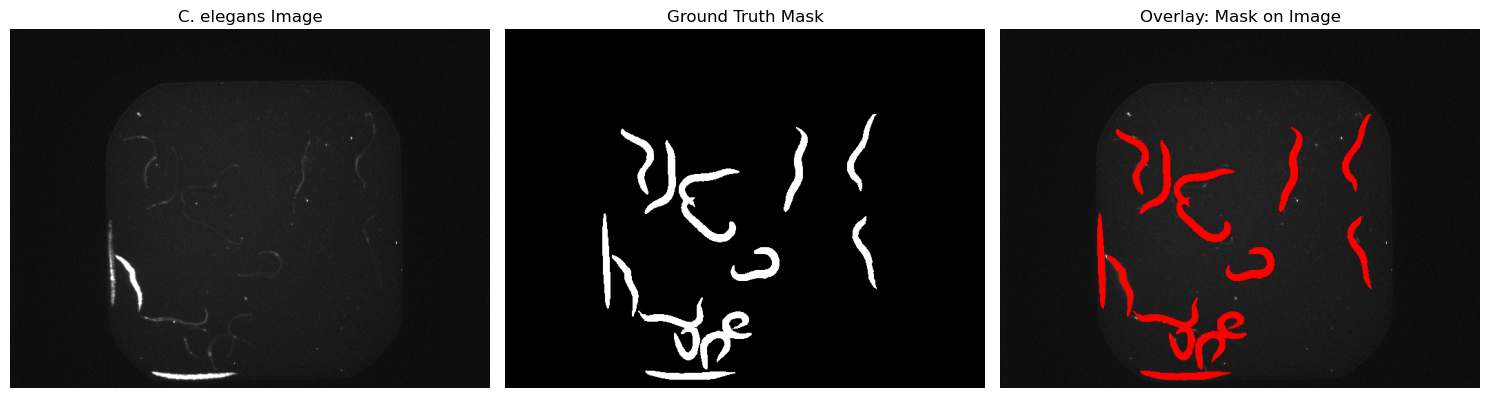

Saved figure: celegans_transfer_figures/step3_celegans_pair_example_1.png

Example 2
Image: 1649_1109_0003_Amp5-1_B_20070424_A15_w1_F938009A-3E83-4CB8-8F76-2D434DFB8E2D.tif
Mask : A15_binary.png
Image shape: (520, 696)
Mask shape : (520, 696)
Image min/max: 81 255
Mask unique values: [  0 255]
Foreground ratio: 0.0392


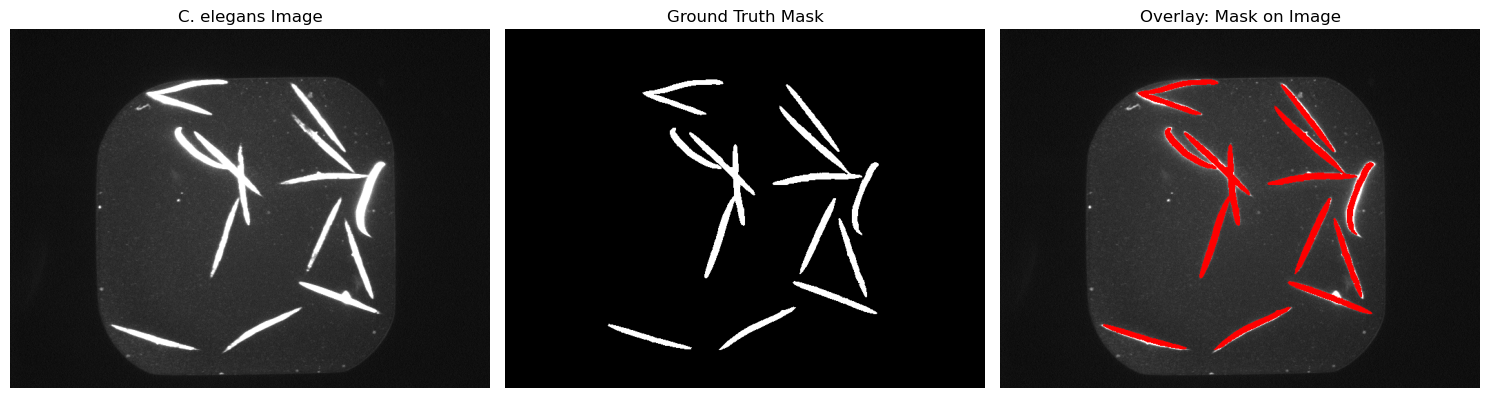

Saved figure: celegans_transfer_figures/step3_celegans_pair_example_2.png

Example 3
Image: 1649_1109_0003_Amp5-1_B_20070424_A04_w1_627EA5BE-2ED8-436F-A347-1BE04E460894.tif
Mask : A04_binary.png
Image shape: (520, 696)
Mask shape : (520, 696)
Image min/max: 81 255
Mask unique values: [  0 255]
Foreground ratio: 0.0405


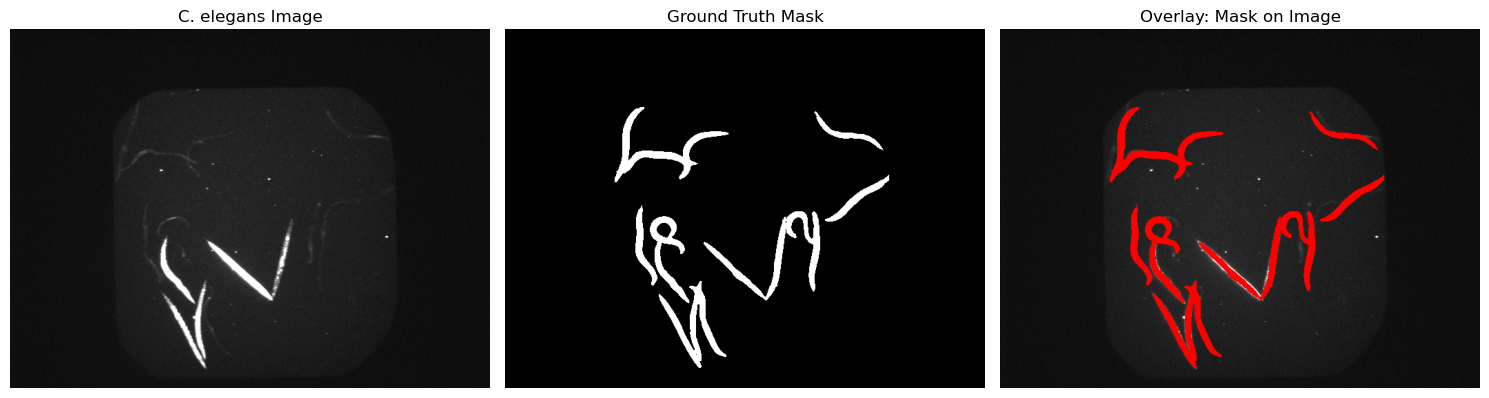

Saved figure: celegans_transfer_figures/step3_celegans_pair_example_3.png

Example 4
Image: 1649_1109_0003_Amp5-1_B_20070424_D23_w1_F58FF4A2-858F-4DA2-8F32-BF5C275FCD23.tif
Mask : D23_binary.png
Image shape: (520, 696)
Mask shape : (520, 696)
Image min/max: 80 255
Mask unique values: [  0 255]
Foreground ratio: 0.0322


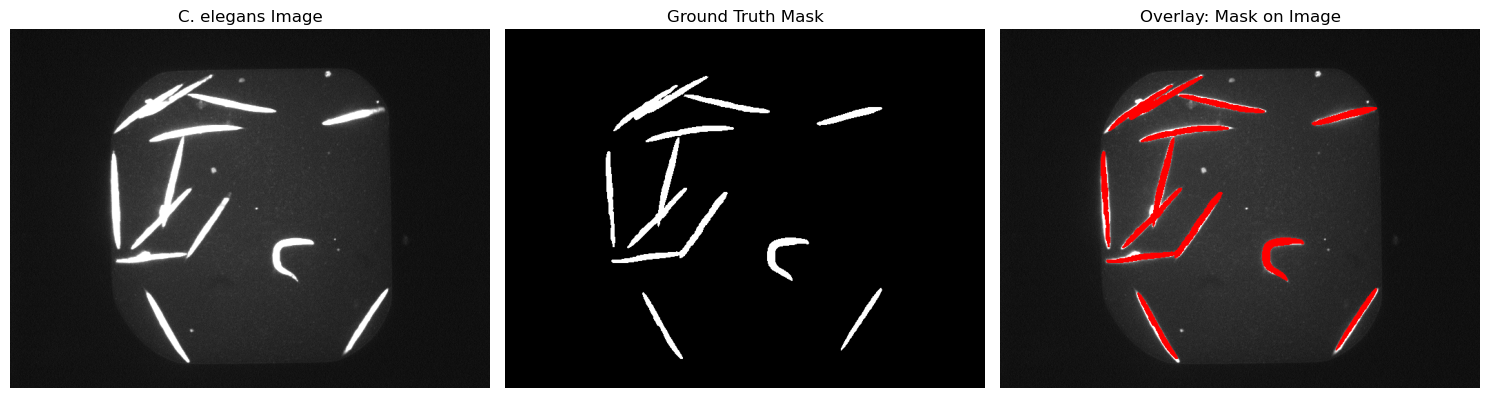

Saved figure: celegans_transfer_figures/step3_celegans_pair_example_4.png

Example 5
Image: 1649_1109_0003_Amp5-1_B_20070424_B12_w1_951039C6-589E-4B0C-9464-3A54CB4C5789.tif
Mask : B12_binary.png
Image shape: (520, 696)
Mask shape : (520, 696)
Image min/max: 79 255
Mask unique values: [  0 255]
Foreground ratio: 0.0404


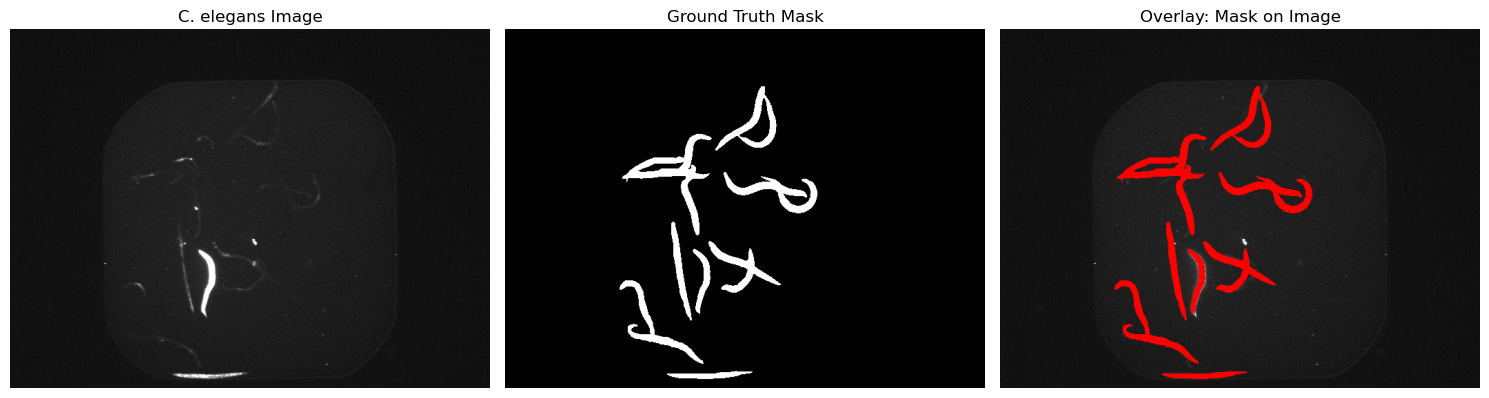

Saved figure: celegans_transfer_figures/step3_celegans_pair_example_5.png


In [4]:
# ============================================================
# STEP 3: Visualize C. elegans image-mask pairs
# ============================================================
# This step verifies that the selected w1 microscopy images match
# the foreground masks correctly.
#
# We show:
#   1. Original grayscale microscopy image
#   2. Binary foreground mask
#   3. Overlay of mask on image
#
# Red overlay = C. elegans foreground region.
# ============================================================

num_examples = 5

sample_indices = random.sample(
    range(len(pairs)),
    min(num_examples, len(pairs))
)

for count, idx in enumerate(sample_indices, start=1):
    img_path, mask_path = pairs[idx]

    # Load grayscale image and mask
    image = Image.open(img_path).convert("L")
    mask = Image.open(mask_path).convert("L")

    image_np = np.array(image)
    mask_np = np.array(mask)

    # Convert mask to binary format
    mask_bin = (mask_np > 0).astype(np.uint8)

    # Normalize image only for display
    image_display = image_np.astype(np.float32)
    image_display = (
        image_display - image_display.min()
    ) / (
        image_display.max() - image_display.min() + 1e-8
    )

    # Create RGB overlay
    overlay = np.stack(
        [image_display, image_display, image_display],
        axis=-1
    )

    overlay[mask_bin == 1] = [1.0, 0.0, 0.0]

    print(f"\nExample {count}")
    print("Image:", os.path.basename(img_path))
    print("Mask :", os.path.basename(mask_path))
    print("Image shape:", image_np.shape)
    print("Mask shape :", mask_np.shape)
    print("Image min/max:", image_np.min(), image_np.max())
    print("Mask unique values:", np.unique(mask_np))
    print(f"Foreground ratio: {mask_bin.mean():.4f}")

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_display, cmap="gray")
    plt.title("C. elegans Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_bin, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay: Mask on Image")
    plt.axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        FIGURE_DIR,
        f"step3_celegans_pair_example_{count}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)

In [5]:
# ============================================================
# STEP 4: Create 96x96 overlapping C. elegans patches
# ============================================================
# This step extracts 96x96 overlapping patches from each C. elegans image
# and its corresponding foreground mask.
#
# Why patches?
#   - The pretrained road model was trained on 96x96 patches.
#   - Using the same patch size makes transfer learning easier.
#
# Important:
#   - We use stride 48, giving 50% overlap.
#   - We keep patches that contain enough foreground pixels.
#   - A small number of empty/background patches are kept so the model
#     also learns background appearance.
#
# Output:
#   celegans_patches is a list of dictionaries.
#   Each dictionary contains:
#       image_patch, mask_patch, foreground_ratio, image_path, mask_path, y, x
# ============================================================

# ----------------------------
# Patch settings
# ----------------------------
PATCH_SIZE = 96
STRIDE = 48

MIN_FOREGROUND_RATIO = 0.005
EMPTY_KEEP_RATIO = 0.05


def normalize_microscopy_image(image_np):
    """
    Normalize one grayscale microscopy image to [0, 1].

    This normalization is done per full image to improve contrast
    before extracting patches.
    """

    image_np = image_np.astype(np.float32)

    min_val = image_np.min()
    max_val = image_np.max()

    if max_val > min_val:
        image_np = (image_np - min_val) / (max_val - min_val)
    else:
        image_np = np.zeros_like(image_np, dtype=np.float32)

    return image_np


def extract_celegans_patches_from_pair(
    img_path,
    mask_path,
    pair_index,
    patch_size=96,
    stride=48,
    min_foreground_ratio=0.005,
    empty_keep_ratio=0.05
):
    """
    Extract image-mask patches from one C. elegans image pair.
    """

    image = Image.open(img_path).convert("L")
    mask = Image.open(mask_path).convert("L")

    image_np = np.array(image)
    mask_np = np.array(mask)

    # Normalize image to [0,1]
    image_np = normalize_microscopy_image(image_np)

    # Binary mask: 0 background, 1 foreground
    mask_bin = (mask_np > 0).astype(np.float32)

    H, W = image_np.shape

    patches = []
    candidate_count = 0
    kept_foreground = 0
    kept_background = 0

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):

            candidate_count += 1

            img_patch = image_np[
                y:y + patch_size,
                x:x + patch_size
            ]

            mask_patch = mask_bin[
                y:y + patch_size,
                x:x + patch_size
            ]

            foreground_ratio = float(mask_patch.mean())

            keep_patch = False
            patch_type = None

            if foreground_ratio >= min_foreground_ratio:
                keep_patch = True
                patch_type = "foreground"
                kept_foreground += 1

            elif random.random() < empty_keep_ratio:
                keep_patch = True
                patch_type = "background"
                kept_background += 1

            if keep_patch:
                patches.append({
                    "image_patch": img_patch,
                    "mask_patch": mask_patch,
                    "foreground_ratio": foreground_ratio,
                    "patch_type": patch_type,
                    "image_path": img_path,
                    "mask_path": mask_path,
                    "pair_index": pair_index,
                    "y": y,
                    "x": x
                })

    return patches, candidate_count, kept_foreground, kept_background


# ----------------------------
# Extract patches from all pairs
# ----------------------------
celegans_patches = []

total_candidates = 0
total_foreground = 0
total_background = 0

for i, (img_path, mask_path) in enumerate(tqdm(pairs, desc="Extracting C. elegans patches")):

    patches_i, candidates_i, foreground_i, background_i = extract_celegans_patches_from_pair(
        img_path,
        mask_path,
        pair_index=i,
        patch_size=PATCH_SIZE,
        stride=STRIDE,
        min_foreground_ratio=MIN_FOREGROUND_RATIO,
        empty_keep_ratio=EMPTY_KEEP_RATIO
    )

    celegans_patches.extend(patches_i)

    total_candidates += candidates_i
    total_foreground += foreground_i
    total_background += background_i


# ----------------------------
# Patch summary
# ----------------------------
print("C. ELEGANS PATCH SUMMARY")
print("------------------------")
print("Full image-mask pairs :", len(pairs))
print("Candidate patches     :", total_candidates)
print("Kept foreground       :", total_foreground)
print("Kept background       :", total_background)
print("Total kept patches    :", len(celegans_patches))

if len(celegans_patches) > 0:
    ratios = [
        p["foreground_ratio"]
        for p in celegans_patches
    ]

    print(f"Mean foreground ratio : {np.mean(ratios):.4f}")
    print(f"Min foreground ratio  : {np.min(ratios):.4f}")
    print(f"Max foreground ratio  : {np.max(ratios):.4f}")
else:
    raise ValueError("No C. elegans patches were extracted. Lower MIN_FOREGROUND_RATIO.")

Extracting C. elegans patches: 100%|██████████| 96/96 [00:01<00:00, 74.70it/s]

C. ELEGANS PATCH SUMMARY
------------------------
Full image-mask pairs : 96
Candidate patches     : 11232
Kept foreground       : 5820
Kept background       : 238
Total kept patches    : 6058
Mean foreground ratio : 0.0878
Min foreground ratio  : 0.0000
Max foreground ratio  : 0.4071


C. elegans image-level split
----------------------------
Total full image IDs: 96
Train image IDs     : 67
Val image IDs       : 14
Test image IDs      : 15

Patch split
-----------
Train patches: 4222
Val patches  : 878
Test patches : 958

Train summary
------------------------------
Number of patches: 4222
Mean foreground ratio: 0.0878
Min foreground ratio : 0.0000
Max foreground ratio : 0.4071

Validation summary
------------------------------
Number of patches: 878
Mean foreground ratio: 0.0856
Min foreground ratio : 0.0000
Max foreground ratio : 0.3483

Test summary
------------------------------
Number of patches: 958
Mean foreground ratio: 0.0902
Min foreground ratio : 0.0000
Max foreground ratio : 0.3290

Patch example 1
Source image: 1649_1109_0003_Amp5-1_B_20070424_B10_w1_812ED8AD-827F-42C9-99EA-397D8BFD65FB.tif
Source mask : B10_binary.png
Location: y = 336 , x = 384
Foreground ratio: 0.0774


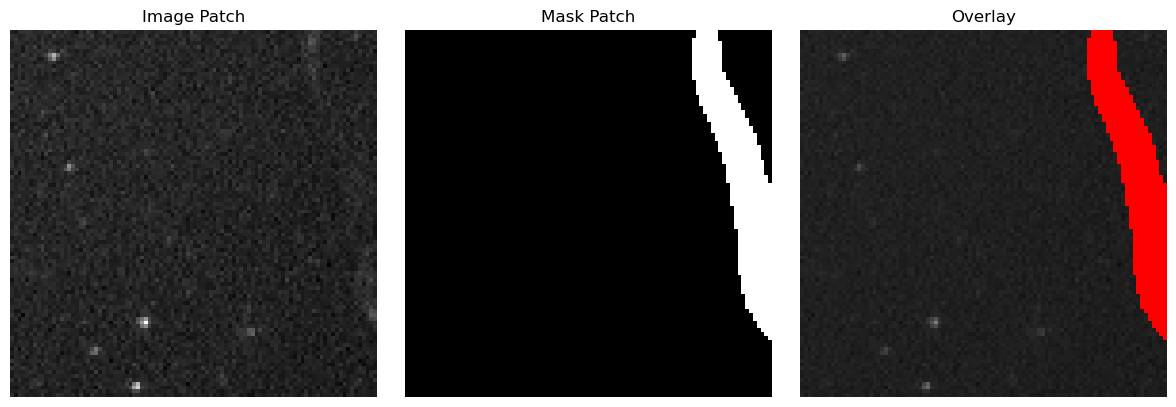

Saved figure: celegans_transfer_figures/step5_celegans_patch_example_1.png

Patch example 2
Source image: 1649_1109_0003_Amp5-1_B_20070424_D05_w1_8C742853-055E-4578-9DF0-EEB99FADF9D0.tif
Source mask : D05_binary.png
Location: y = 240 , x = 480
Foreground ratio: 0.1100


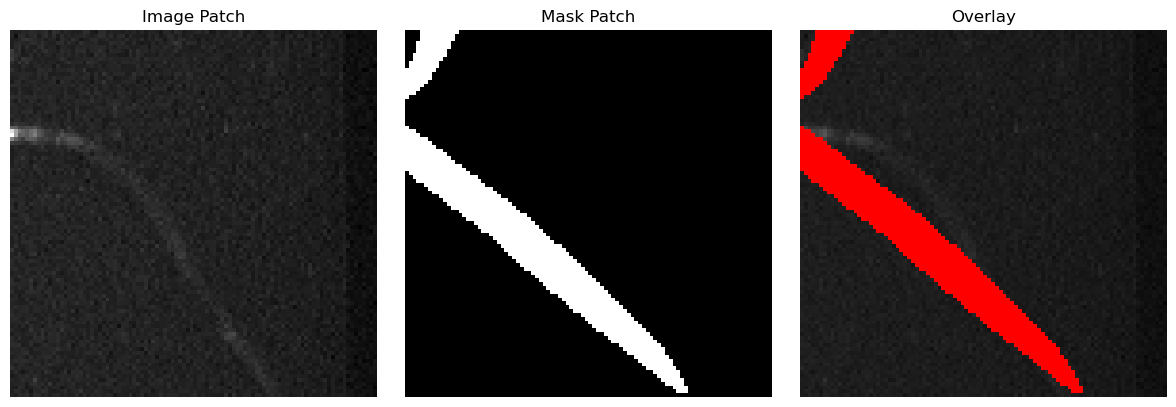

Saved figure: celegans_transfer_figures/step5_celegans_patch_example_2.png

Patch example 3
Source image: 1649_1109_0003_Amp5-1_B_20070424_B22_w1_81E0BD09-900A-402B-9162-3E43C71AA0DE.tif
Source mask : B22_binary.png
Location: y = 144 , x = 240
Foreground ratio: 0.0650


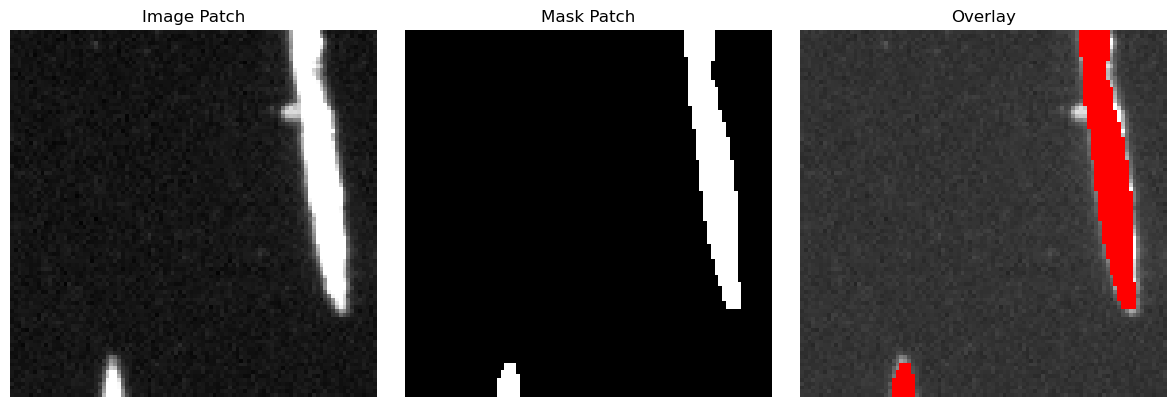

Saved figure: celegans_transfer_figures/step5_celegans_patch_example_3.png

Patch example 4
Source image: 1649_1109_0003_Amp5-1_B_20070424_B10_w1_812ED8AD-827F-42C9-99EA-397D8BFD65FB.tif
Source mask : B10_binary.png
Location: y = 384 , x = 432
Foreground ratio: 0.0523


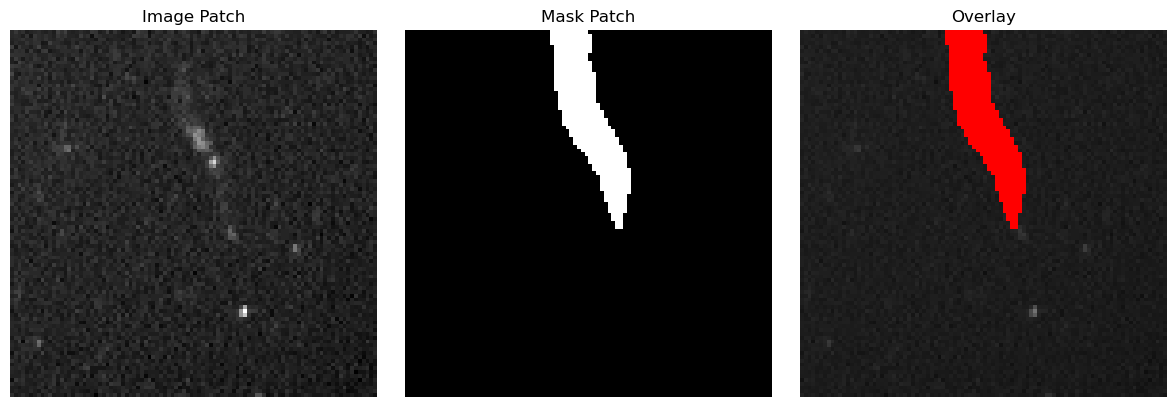

Saved figure: celegans_transfer_figures/step5_celegans_patch_example_4.png

Patch example 5
Source image: 1649_1109_0003_Amp5-1_B_20070424_D18_w1_EA00B7CA-24E0-46F2-AAA9-F0E900F17C68.tif
Source mask : D18_binary.png
Location: y = 48 , x = 336
Foreground ratio: 0.1377


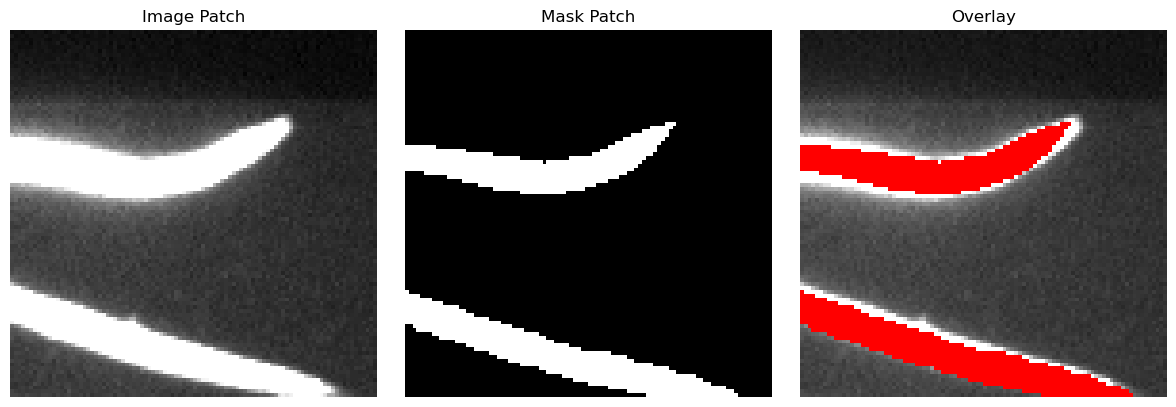

Saved figure: celegans_transfer_figures/step5_celegans_patch_example_5.png


In [6]:
# ============================================================
# STEP 5: Split C. elegans patches and visualize examples
# ============================================================
# This step does two important things:
#
# 1. Split patches into train, validation, and test sets.
#    The split is done by pair_index, not randomly by patch.
#    This avoids data leakage because patches from the same full image
#    should not appear in both training and testing.
#
# 2. Visualize selected patch examples to verify that image patches
#    and masks are correctly aligned.
# ============================================================

# ----------------------------
# Split full image pair IDs
# ----------------------------
pair_ids = sorted(
    list(set([p["pair_index"] for p in celegans_patches]))
)

random.seed(SEED)
random.shuffle(pair_ids)

n_total = len(pair_ids)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_pair_ids = set(pair_ids[:n_train])
val_pair_ids = set(pair_ids[n_train:n_train + n_val])
test_pair_ids = set(pair_ids[n_train + n_val:])

train_patches = [
    p for p in celegans_patches
    if p["pair_index"] in train_pair_ids
]

val_patches = [
    p for p in celegans_patches
    if p["pair_index"] in val_pair_ids
]

test_patches = [
    p for p in celegans_patches
    if p["pair_index"] in test_pair_ids
]

print("C. elegans image-level split")
print("----------------------------")
print("Total full image IDs:", n_total)
print("Train image IDs     :", len(train_pair_ids))
print("Val image IDs       :", len(val_pair_ids))
print("Test image IDs      :", len(test_pair_ids))

print("\nPatch split")
print("-----------")
print("Train patches:", len(train_patches))
print("Val patches  :", len(val_patches))
print("Test patches :", len(test_patches))


# ----------------------------
# Patch summary helper
# ----------------------------
def summarize_celegans_split(patches, split_name):
    ratios = [
        p["foreground_ratio"]
        for p in patches
    ]

    print(f"\n{split_name} summary")
    print("-" * 30)
    print("Number of patches:", len(patches))

    if len(ratios) > 0:
        print(f"Mean foreground ratio: {np.mean(ratios):.4f}")
        print(f"Min foreground ratio : {np.min(ratios):.4f}")
        print(f"Max foreground ratio : {np.max(ratios):.4f}")


summarize_celegans_split(train_patches, "Train")
summarize_celegans_split(val_patches, "Validation")
summarize_celegans_split(test_patches, "Test")


# ============================================================
# Visualize selected foreground-rich patch examples
# ============================================================

foreground_indices = [
    i for i, p in enumerate(train_patches)
    if p["foreground_ratio"] >= 0.05
]

num_examples = min(5, len(foreground_indices))

if num_examples > 0:
    selected_indices = random.sample(
        foreground_indices,
        num_examples
    )
else:
    selected_indices = random.sample(
        range(len(train_patches)),
        min(5, len(train_patches))
    )

for count, idx in enumerate(selected_indices, start=1):
    patch = train_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    mask_bin = mask_patch.astype(np.uint8)

    image_display = image_patch.astype(np.float32)

    overlay = np.stack(
        [image_display, image_display, image_display],
        axis=-1
    )

    overlay[mask_bin == 1] = [1.0, 0.0, 0.0]

    print(f"\nPatch example {count}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Source mask :", os.path.basename(patch["mask_path"]))
    print("Location: y =", patch["y"], ", x =", patch["x"])
    print(f"Foreground ratio: {patch['foreground_ratio']:.4f}")

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image_display, cmap="gray")
    plt.title("Image Patch")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_bin, cmap="gray")
    plt.title("Mask Patch")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        FIGURE_DIR,
        f"step5_celegans_patch_example_{count}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)

In [7]:
# ============================================================
# STEP 6: Create C. elegans PyTorch datasets and dataloaders
# ============================================================
# This step converts the C. elegans image-mask patches into PyTorch tensors.
#
# Important:
# The pretrained road model expects 3-channel input.
# C. elegans images are grayscale, so each grayscale patch is repeated
# across 3 channels:
#
#   [1, 96, 96]  ->  [3, 96, 96]
#
# Final tensor shapes:
#   image: [3, 96, 96]
#   mask : [1, 96, 96]
# ============================================================

class CElegansPatchDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch = self.patches[idx]

        image_patch = patch["image_patch"].astype(np.float32)
        mask_patch = patch["mask_patch"].astype(np.float32)

        # Grayscale image [H,W] -> [1,H,W]
        image_tensor = torch.from_numpy(image_patch).unsqueeze(0)

        # Repeat grayscale channel to match pretrained road model input [3,H,W]
        image_tensor = image_tensor.repeat(3, 1, 1)

        # Mask [H,W] -> [1,H,W]
        mask_tensor = torch.from_numpy(mask_patch).unsqueeze(0)

        return image_tensor, mask_tensor


# ----------------------------
# Create dataset objects
# ----------------------------
train_dataset = CElegansPatchDataset(train_patches)
val_dataset = CElegansPatchDataset(val_patches)
test_dataset = CElegansPatchDataset(test_patches)


# ----------------------------
# Create dataloaders
# ----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ----------------------------
# Check one batch
# ----------------------------
images, masks = next(iter(train_loader))

print("Train dataset size     :", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size      :", len(test_dataset))

print("\nTrain batches     :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

print("\nImage batch shape:", images.shape)
print("Mask batch shape :", masks.shape)

print("\nImage min:", images.min().item())
print("Image max:", images.max().item())
print("Mask unique values:", torch.unique(masks))
print("Batch foreground ratio:", masks.mean().item())

Train dataset size     : 4222
Validation dataset size: 878
Test dataset size      : 958

Train batches     : 528
Validation batches: 110
Test batches      : 120

Image batch shape: torch.Size([8, 3, 96, 96])
Mask batch shape : torch.Size([8, 1, 96, 96])

Image min: 0.02298850566148758
Image max: 1.0
Mask unique values: tensor([0., 1.])
Batch foreground ratio: 0.1015082448720932


In [13]:
# ============================================================
# LOAD PRETRAINED ROAD MODEL 5
# ============================================================

PRETRAINED_ROAD_MODEL_PATH = (
    "/home/mutie/final_thesis_models/"
    "best_hybrid_sat_creator_model.pth"
)

print("Loading pretrained Road Model 5 from:")
print(PRETRAINED_ROAD_MODEL_PATH)

pretrained_state = torch.load(
    PRETRAINED_ROAD_MODEL_PATH,
    map_location=device
)

missing_keys, unexpected_keys = celegans_model.load_state_dict(
    pretrained_state,
    strict=False
)

print("\nPretrained Road Model 5 loaded successfully.")
print("Missing keys:", missing_keys)
print("Unexpected keys:", unexpected_keys)

Loading pretrained Road Model 5 from:
/home/mutie/final_thesis_models/best_hybrid_sat_creator_model.pth

Pretrained Road Model 5 loaded successfully.
Missing keys: []
Unexpected keys: []


In [14]:
# ============================================================
# STEP 7: Define U-Net and load pretrained Road Model 5
# ============================================================
# This step prepares the transfer-learning model.
#
# Source model:
#   Road Model 5( best):
#   BCE + Dice + soft-clDice + SATLoss Creator
#
# Target task:
#   C. elegans foreground segmentation
#
# Since the C. elegans images were converted to 3 channels, the input shape
# matches the pretrained road model:
#   [B, 3, 96, 96]
# ============================================================

# ----------------------------
# U-Net building block
# ----------------------------
class DoubleConv(nn.Module):
    """
    Two convolution layers with BatchNorm and ReLU.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.double_conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


# ----------------------------
# U-Net model
# ----------------------------
class UNet(nn.Module):
    """
    U-Net segmentation model.

    This architecture must match the road model architecture exactly,
    otherwise pretrained weights cannot be loaded.
    """

    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(u4)

        u3 = self.up3(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(u3)

        u2 = self.up2(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(u2)

        u1 = self.up1(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(u1)

        logits = self.final_conv(c8)

        return logits


# ----------------------------
# Create transfer model
# ----------------------------
celegans_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)


# ----------------------------
# Load pretrained Road Model 5
# ----------------------------
if not os.path.exists(PRETRAINED_ROAD_MODEL_PATH):
    raise FileNotFoundError(
        f"Pretrained road model not found: {PRETRAINED_ROAD_MODEL_PATH}"
    )

pretrained_state = torch.load(
    PRETRAINED_ROAD_MODEL_PATH,
    map_location=device
)

celegans_model.load_state_dict(pretrained_state)

print("Loaded pretrained Road Model 5 successfully.")
print("Pretrained model path:", PRETRAINED_ROAD_MODEL_PATH)


# ----------------------------
# Test one forward pass
# ----------------------------
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

celegans_model.eval()

with torch.no_grad():
    logits = celegans_model(images)

print("\nForward pass test")
print("-----------------")
print("Input image shape :", images.shape)
print("Output logits shape:", logits.shape)
print("Expected mask shape:", masks.shape)

assert logits.shape == masks.shape, "Output shape does not match mask shape."

num_params = sum(
    p.numel()
    for p in celegans_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", num_params)

Loaded pretrained Road Model 5 successfully.
Pretrained model path: /home/mutie/final_thesis_models/best_hybrid_sat_creator_model.pth

Forward pass test
-----------------
Input image shape : torch.Size([8, 3, 96, 96])
Output logits shape: torch.Size([8, 1, 96, 96])
Expected mask shape: torch.Size([8, 1, 96, 96])
Trainable parameters: 31037633


In [15]:
# ============================================================
# STEP 8: Define losses and evaluation metrics for C. elegans
# ============================================================
# This step defines the training losses and evaluation metrics.
#
# Training loss:
#   BCE + Dice loss + soft-clDice loss
#
# Evaluation metrics:
#   Accuracy
#   Dice
#   clDice
#   beta0 error
#   beta1 error
#
# beta0 measures connected components.
# beta1 measures holes/loops.
# ============================================================

# ----------------------------
# BCE loss
# ----------------------------
bce_loss_fn = nn.BCEWithLogitsLoss()


# ----------------------------
# Dice loss and Dice score
# ----------------------------
def dice_loss(probs, targets, eps=1e-8):
    probs = probs.float()
    targets = targets.float()

    intersection = (probs * targets).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (union + eps)

    return 1.0 - dice.mean()


def dice_score(preds, targets, eps=1e-8):
    preds = preds.float()
    targets = targets.float()

    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()

    dice = (2.0 * intersection + eps) / (union + eps)

    return dice.item()


# ----------------------------
# Accuracy
# ----------------------------
def accuracy_score(preds, targets):
    correct = (preds == targets).float().sum()
    total = torch.numel(targets)

    return (correct / total).item()


# ----------------------------
# soft-clDice loss
# ----------------------------
CLDICE_ITERATIONS = 3

def soft_erode(img):
    p1 = -F.max_pool2d(
        -img,
        kernel_size=(3, 1),
        stride=1,
        padding=(1, 0)
    )

    p2 = -F.max_pool2d(
        -img,
        kernel_size=(1, 3),
        stride=1,
        padding=(0, 1)
    )

    return torch.min(p1, p2)


def soft_dilate(img):
    return F.max_pool2d(
        img,
        kernel_size=3,
        stride=1,
        padding=1
    )


def soft_open(img):
    return soft_dilate(soft_erode(img))


def soft_skeletonize(img, iterations=3):
    img = img.float()

    opened = soft_open(img)
    skeleton = F.relu(img - opened)

    for _ in range(iterations):
        img = soft_erode(img)
        opened = soft_open(img)

        delta = F.relu(img - opened)
        skeleton = skeleton + F.relu(delta - skeleton * delta)

    return skeleton


def soft_cldice_loss(probs, targets, iterations=3, eps=1e-8):
    probs = probs.float()
    targets = targets.float()

    skel_pred = soft_skeletonize(
        probs,
        iterations=iterations
    )

    skel_true = soft_skeletonize(
        targets,
        iterations=iterations
    )

    tprec = (skel_pred * targets).sum(dim=(1, 2, 3)) / (
        skel_pred.sum(dim=(1, 2, 3)) + eps
    )

    tsens = (skel_true * probs).sum(dim=(1, 2, 3)) / (
        skel_true.sum(dim=(1, 2, 3)) + eps
    )

    cldice = (2.0 * tprec * tsens + eps) / (
        tprec + tsens + eps
    )

    return 1.0 - cldice.mean()


# ----------------------------
# clDice score for evaluation
# ----------------------------
def cldice_score(pred_np, target_np, eps=1e-8):
    pred_np = pred_np.astype(bool)
    target_np = target_np.astype(bool)

    skel_pred = skeletonize(pred_np)
    skel_target = skeletonize(target_np)

    if skel_pred.sum() == 0 and skel_target.sum() == 0:
        return 1.0

    if skel_pred.sum() == 0 or skel_target.sum() == 0:
        return 0.0

    tprec = (skel_pred * target_np).sum() / (
        skel_pred.sum() + eps
    )

    tsens = (skel_target * pred_np).sum() / (
        skel_target.sum() + eps
    )

    return float(
        (2.0 * tprec * tsens) / (tprec + tsens + eps)
    )


# ----------------------------
# Betti numbers
# ----------------------------
def betti_numbers(binary_np):
    binary_np = binary_np.astype(bool)

    labeled_fg = label(binary_np, connectivity=2)
    beta0 = labeled_fg.max()

    filled = binary_fill_holes(binary_np)
    holes = filled & (~binary_np)

    labeled_holes = label(holes, connectivity=2)
    beta1 = labeled_holes.max()

    return beta0, beta1


def betti_error(pred_np, target_np):
    b0_pred, b1_pred = betti_numbers(pred_np)
    b0_true, b1_true = betti_numbers(target_np)

    return abs(b0_pred - b0_true), abs(b1_pred - b1_true)


# ----------------------------
# Evaluation function
# ----------------------------
def evaluate_celegans_model(model, loader, device, threshold=0.5):
    model.eval()

    loss_values = []
    acc_values = []
    dice_values = []
    cldice_values = []
    beta0_values = []
    beta1_values = []

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating C. elegans"):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)
            closs = soft_cldice_loss(
                probs,
                masks,
                iterations=CLDICE_ITERATIONS
            )

            loss = bce + dloss + closs

            loss_values.append(loss.item())
            acc_values.append(accuracy_score(preds.cpu(), masks.cpu()))
            dice_values.append(dice_score(preds.cpu(), masks.cpu()))

            for i in range(images.shape[0]):
                pred_np = preds[i, 0].cpu().numpy().astype(np.uint8)
                mask_np = masks[i, 0].cpu().numpy().astype(np.uint8)

                cldice_values.append(
                    cldice_score(pred_np, mask_np)
                )

                b0_err, b1_err = betti_error(pred_np, mask_np)
                beta0_values.append(b0_err)
                beta1_values.append(b1_err)

    return {
        "loss": float(np.mean(loss_values)),
        "accuracy": float(np.mean(acc_values)),
        "dice": float(np.mean(dice_values)),
        "cldice": float(np.mean(cldice_values)),
        "beta0_error": float(np.mean(beta0_values)),
        "beta1_error": float(np.mean(beta1_values)),
        "threshold": threshold
    }


# ----------------------------
# Quick test before training
# ----------------------------
celegans_model.eval()

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = celegans_model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

print("Quick metric test before C. elegans fine-tuning")
print("-----------------------------------------------")
print("BCE loss:", bce_loss_fn(logits, masks).item())
print("Dice loss:", dice_loss(probs, masks).item())
print("soft-clDice loss:", soft_cldice_loss(probs, masks).item())
print("Accuracy:", accuracy_score(preds.cpu(), masks.cpu()))
print("Dice:", dice_score(preds.cpu(), masks.cpu()))

Quick metric test before C. elegans fine-tuning
-----------------------------------------------
BCE loss: 0.41194504499435425
Dice loss: 0.8620247840881348
soft-clDice loss: 0.9444440603256226
Accuracy: 0.8960232138633728
Dice: 0.1603504866361618


In [16]:
# ============================================================
# STEP 9: Fine-tune pretrained Road Model 5 on C. elegans
# ============================================================
# This step fine-tunes the pretrained topology-aware road model on the
# C. elegans segmentation task.
#
# Starting model:
#   Road Model 5 = BCE + Dice + soft-clDice + SATLoss Creator
#
# Fine-tuning loss:
#   L = BCE + Dice loss + soft-clDice loss
#
# We do not use SATLoss here to keep training stable on the smaller
# C. elegans dataset.
#
# Best model is saved using validation Dice.
# ============================================================

CELEGANS_EPOCHS = 30
CELEGANS_LR = 1e-4
CELEGANS_WEIGHT_DECAY = 1e-4

celegans_optimizer = optim.Adam(
    celegans_model.parameters(),
    lr=CELEGANS_LR,
    weight_decay=CELEGANS_WEIGHT_DECAY
)

celegans_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    celegans_optimizer,
    mode="max",
    factor=0.5,
    patience=4
)

scaler = torch.cuda.amp.GradScaler()

celegans_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_dice_loss": [],
    "train_cldice_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": []
}


def train_one_epoch_celegans(
    model,
    loader,
    optimizer,
    scaler,
    device
):
    model.train()

    total_loss = 0.0
    total_bce = 0.0
    total_dice = 0.0
    total_cldice = 0.0

    for images, masks in tqdm(loader, desc="Training C. elegans"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)

        closs = soft_cldice_loss(
            probs.float(),
            masks.float(),
            iterations=CLDICE_ITERATIONS
        )

        loss = bce + dloss + closs

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_dice += dloss.item()
        total_cldice += closs.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "dice": total_dice / len(loader),
        "cldice": total_cldice / len(loader)
    }


best_celegans_dice = -1.0
best_celegans_state = None

for epoch in range(CELEGANS_EPOCHS):

    print(f"\nC. elegans Fine-tuning Epoch {epoch + 1}/{CELEGANS_EPOCHS}")
    print("-" * 60)

    train_metrics = train_one_epoch_celegans(
        celegans_model,
        train_loader,
        celegans_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_celegans_model(
        celegans_model,
        val_loader,
        device,
        threshold=0.5
    )

    celegans_scheduler.step(val_metrics["dice"])

    celegans_history["train_total_loss"].append(train_metrics["loss"])
    celegans_history["train_bce_loss"].append(train_metrics["bce"])
    celegans_history["train_dice_loss"].append(train_metrics["dice"])
    celegans_history["train_cldice_loss"].append(train_metrics["cldice"])

    celegans_history["val_loss"].append(val_metrics["loss"])
    celegans_history["val_accuracy"].append(val_metrics["accuracy"])
    celegans_history["val_dice"].append(val_metrics["dice"])
    celegans_history["val_cldice"].append(val_metrics["cldice"])
    celegans_history["val_beta0_error"].append(val_metrics["beta0_error"])
    celegans_history["val_beta1_error"].append(val_metrics["beta1_error"])

    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train Dice Loss  : {train_metrics['dice']:.4f}")
    print(f"Train clDice Loss: {train_metrics['cldice']:.4f}")

    print(f"Val Loss         : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")

    current_lr = celegans_optimizer.param_groups[0]["lr"]
    print(f"Learning rate    : {current_lr:.6f}")

    if val_metrics["dice"] > best_celegans_dice:

        best_celegans_dice = val_metrics["dice"]
        best_celegans_state = copy.deepcopy(
            celegans_model.state_dict()
        )

        torch.save(
            best_celegans_state,
            os.path.join(
                SAVE_DIR,
                "best_celegans_transfer_model.pth"
            )
        )

        print("Best C. elegans transfer model saved.")

print("\nC. elegans fine-tuning finished.")
print("Best validation Dice:", best_celegans_dice)


C. elegans Fine-tuning Epoch 1/30
------------------------------------------------------------


Evaluating C. elegans: 100%|██████████| 110/110 [00:08<00:00, 12.74it/s]


Train Total Loss : 0.7527
Train BCE Loss   : 0.1439
Train Dice Loss  : 0.3428
Train clDice Loss: 0.2660
Val Loss         : 0.6129
Val Accuracy     : 0.9639
Val Dice         : 0.7944
Val clDice       : 0.8505
Val beta0 err    : 0.3462
Val beta1 err    : 0.1378
Learning rate    : 0.000100
Best C. elegans transfer model saved.

C. elegans Fine-tuning Epoch 2/30
------------------------------------------------------------


Evaluating C. elegans: 100%|██████████| 110/110 [00:08<00:00, 12.23it/s]


Train Total Loss : 0.6517
Train BCE Loss   : 0.1255
Train Dice Loss  : 0.3027
Train clDice Loss: 0.2236
Val Loss         : 0.6002
Val Accuracy     : 0.9645
Val Dice         : 0.7983
Val clDice       : 0.8541
Val beta0 err    : 0.3257
Val beta1 err    : 0.1481
Learning rate    : 0.000100
Best C. elegans transfer model saved.

C. elegans Fine-tuning Epoch 3/30
------------------------------------------------------------


...

Train Total Loss : 0.1877
Train BCE Loss   : 0.0346
Train Dice Loss  : 0.1046
Train clDice Loss: 0.0485
Val Loss         : 0.7730
Val Accuracy     : 0.9658
Val Dice         : 0.7838
Val clDice       : 0.8220
Val beta0 err    : 0.3861
Val beta1 err    : 0.1424
Learning rate    : 0.000013

C. elegans Fine-tuning Epoch 29/30
------------------------------------------------------------


Evaluating C. elegans: 100%|██████████| 110/110 [00:09<00:00, 11.66it/s]


Train Total Loss : 0.1850
Train BCE Loss   : 0.0336
Train Dice Loss  : 0.1031
Train clDice Loss: 0.0484
Val Loss         : 0.7746
Val Accuracy     : 0.9659
Val Dice         : 0.7852
Val clDice       : 0.8225
Val beta0 err    : 0.3907
Val beta1 err    : 0.1424
Learning rate    : 0.000006

C. elegans Fine-tuning Epoch 30/30
------------------------------------------------------------


Evaluating C. elegans: 100%|██████████| 110/110 [00:05<00:00, 18.86it/s]

Train Total Loss : 0.1807
Train BCE Loss   : 0.0323
Train Dice Loss  : 0.1007
Train clDice Loss: 0.0477
Val Loss         : 0.7797
Val Accuracy     : 0.9659
Val Dice         : 0.7838
Val clDice       : 0.8213
Val beta0 err    : 0.3964
Val beta1 err    : 0.1446
Learning rate    : 0.000006

C. elegans fine-tuning finished.
Best validation Dice: 0.8084485406225378


In [17]:
# ============================================================
# STEP 10: Final evaluation of C. elegans transfer model
# ============================================================
# This step evaluates the best saved transfer-learning model on the test set.
#
# Model:
#   Road Model 5 transferred to C. elegans
#
# Training loss:
#   BCE + Dice + soft-clDice
#
# The best checkpoint was selected using validation Dice.
# ============================================================

# ----------------------------
# Load best C. elegans transfer model
# ----------------------------
final_celegans_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_celegans_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_celegans_transfer_model.pth"),
        map_location=device
    )
)

final_celegans_model.eval()

# ----------------------------
# Evaluate on test set
# ----------------------------
celegans_test_metrics = evaluate_celegans_model(
    final_celegans_model,
    test_loader,
    device,
    threshold=0.5
)

# ----------------------------
# Print final test results
# ----------------------------
print("FINAL TEST RESULTS: C. elegans Transfer Learning")
print("------------------------------------------------")
print(f"Test Loss       : {celegans_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {celegans_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {celegans_test_metrics['dice']:.4f}")
print(f"Test clDice     : {celegans_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {celegans_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {celegans_test_metrics['beta1_error']:.4f}")
print(f"Threshold       : {celegans_test_metrics['threshold']:.4f}")

# ----------------------------
# Save final test results
# ----------------------------
celegans_result = {
    "Model": "Road Model 5 Transfer to C. elegans",
    "Loss": celegans_test_metrics["loss"],
    "Accuracy": celegans_test_metrics["accuracy"],
    "Dice": celegans_test_metrics["dice"],
    "clDice": celegans_test_metrics["cldice"],
    "beta0_error": celegans_test_metrics["beta0_error"],
    "beta1_error": celegans_test_metrics["beta1_error"],
    "Threshold": celegans_test_metrics["threshold"]
}

celegans_results_df = pd.DataFrame([celegans_result])

celegans_results_path = os.path.join(
    RESULTS_DIR,
    "celegans_transfer_test_results.csv"
)

celegans_results_df.to_csv(
    celegans_results_path,
    index=False
)

print("\nSaved C. elegans test results to:")
print(celegans_results_path)

Evaluating C. elegans: 100%|██████████| 120/120 [00:07<00:00, 17.08it/s]

FINAL TEST RESULTS: C. elegans Transfer Learning
------------------------------------------------
Test Loss       : 0.8255
Test Accuracy   : 0.9539
Test Dice       : 0.7449
Test clDice     : 0.7727
Test beta0 err  : 0.3904
Test beta1 err  : 0.0950
Threshold       : 0.5000

Saved C. elegans test results to:
celegans_transfer_results/celegans_transfer_test_results.csv


Selected test patch indices: [769, 606, 690, 216, 399, 211, 378, 862]

Patch 1
Source image: 1649_1109_0003_Amp5-1_B_20070424_D10_w1_8D8C78DF-1B1A-4FFC-9801-509ED7E63D2E.tif
Location: y = 96 , x = 144
Ground-truth foreground ratio: 8.75%
Predicted foreground ratio   : 8.44%

Patch 2
Source image: 1649_1109_0003_Amp5-1_B_20070424_C07_w1_0652E7B6-2C98-4439-96B3-7EC6F2FE56C6.tif
Location: y = 192 , x = 192
Ground-truth foreground ratio: 5.39%
Predicted foreground ratio   : 5.05%

Patch 3
Source image: 1649_1109_0003_Amp5-1_B_20070424_C22_w1_4DC22374-DA59-4A16-8A6B-0654C2C11848.tif
Location: y = 288 , x = 384
Ground-truth foreground ratio: 14.15%
Predicted foreground ratio   : 13.78%

Patch 4
Source image: 1649_1109_0003_Amp5-1_B_20070424_A14_w1_7CE1172C-A1D6-4FCB-ABB8-B79EFF3693BC.tif
Location: y = 144 , x = 48
Ground-truth foreground ratio: 8.20%
Predicted foreground ratio   : 8.42%

Patch 5
Source image: 1649_1109_0003_Amp5-1_B_20070424_A18_w1_87E6046F-BFD2-48F3-AF88-E820FDDFF871.tif
Lo

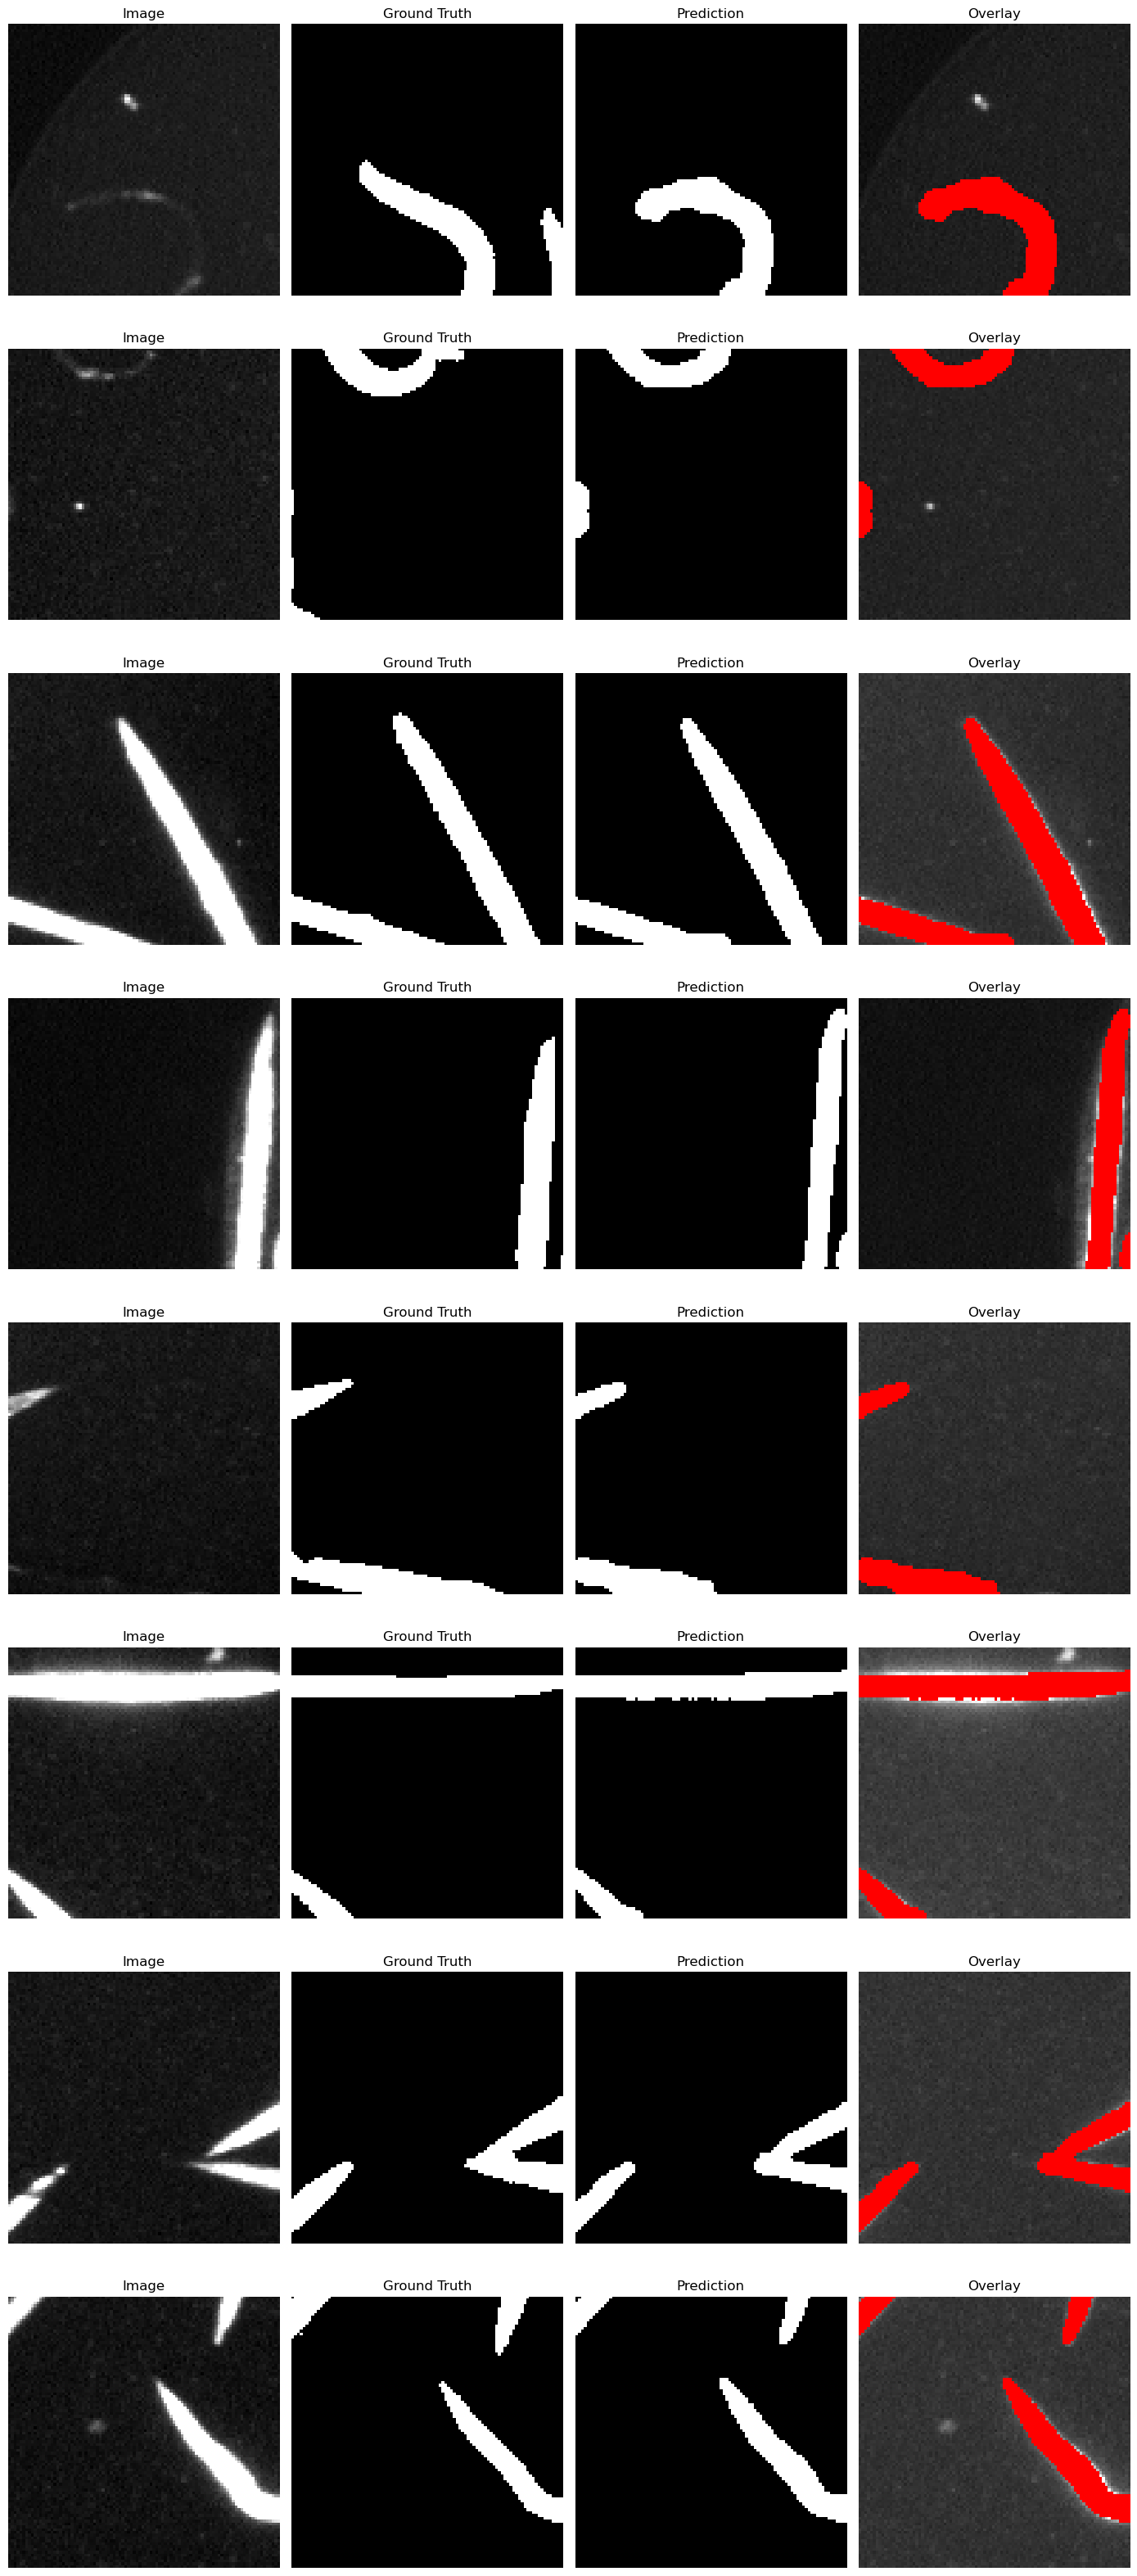


Saved C. elegans prediction visualization to:
celegans_transfer_figures/step11_celegans_transfer_test_predictions.png


In [18]:
# ============================================================
# STEP 11: Visualize C. elegans test predictions
# ============================================================
# This step visualizes predictions from the final transfer-learning model.
#
# Columns:
#   Image | Ground Truth | Prediction | Overlay
#
# Red overlay = predicted C. elegans foreground.
# ============================================================

final_celegans_model.eval()

# ----------------------------
# Select foreground-rich test patches
# ----------------------------
foreground_indices = [
    i for i, p in enumerate(test_patches)
    if p["foreground_ratio"] >= 0.05
]

num_samples = 8

if len(foreground_indices) >= num_samples:
    selected_indices = random.sample(foreground_indices, num_samples)
else:
    selected_indices = random.sample(
        range(len(test_patches)),
        min(num_samples, len(test_patches))
    )

print("Selected test patch indices:", selected_indices)


# ----------------------------
# Visualize predictions
# ----------------------------
plt.figure(figsize=(14, 4 * len(selected_indices)))

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32)
    ).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_celegans_model(image_tensor)
        probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)

    image_display = image_patch.astype(np.float32)
    mask_np = mask_patch.astype(np.uint8)

    overlay = np.stack(
        [image_display, image_display, image_display],
        axis=-1
    )

    overlay[pred_np == 1] = [1.0, 0.0, 0.0]

    print(f"\nPatch {row + 1}")
    print("Source image:", os.path.basename(patch["image_path"]))
    print("Location: y =", patch["y"], ", x =", patch["x"])
    print(f"Ground-truth foreground ratio: {patch['foreground_ratio'] * 100:.2f}%")
    print(f"Predicted foreground ratio   : {pred_np.mean() * 100:.2f}%")

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display, cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step11_celegans_transfer_test_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved C. elegans prediction visualization to:")
print(save_path)

Saved final C. elegans model to:
celegans_transfer_models/final_celegans_transfer_from_road_model5.pth

Saved training history to:
celegans_transfer_results/celegans_training_history.pkl


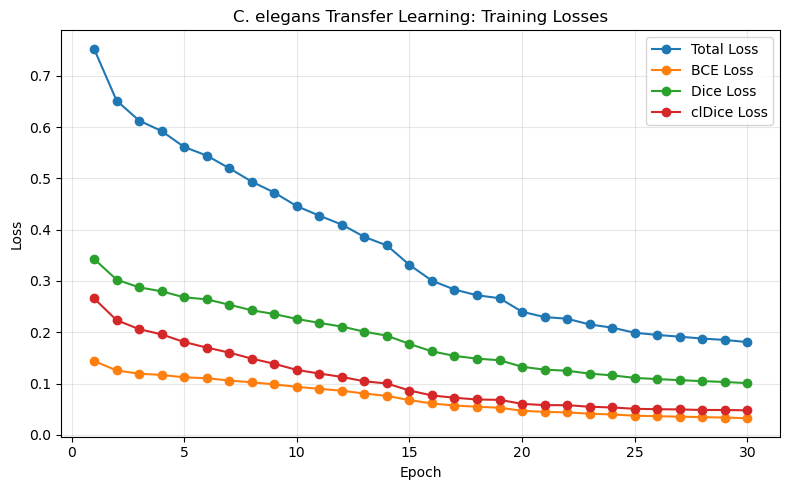

Saved: celegans_transfer_figures/step12_celegans_training_losses.png


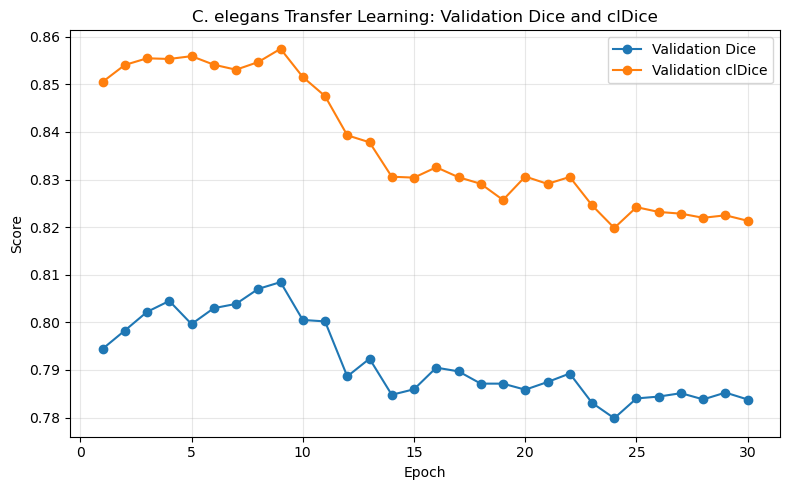

Saved: celegans_transfer_figures/step12_celegans_val_dice_cldice.png


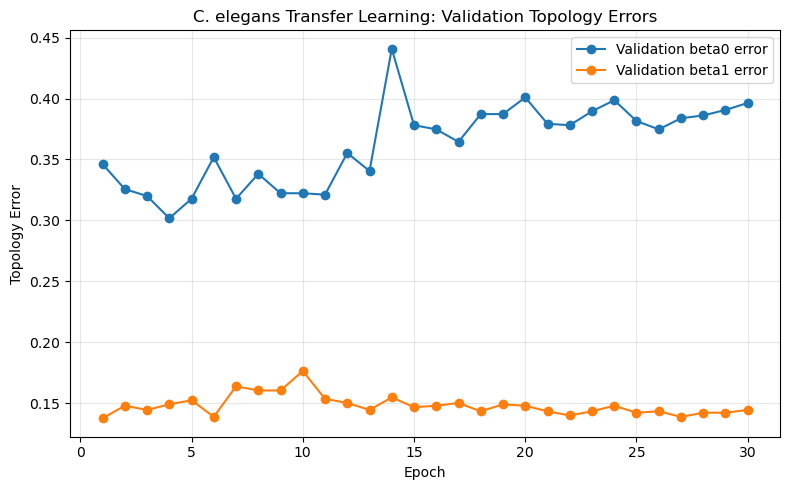

Saved: celegans_transfer_figures/step12_celegans_topology_errors.png

Saved experiment summary to:
celegans_transfer_results/celegans_transfer_experiment_summary.json


In [19]:
# ============================================================
# STEP 12: Save final C. elegans model, results, and training curves
# ============================================================
# This step saves all important C. elegans transfer-learning outputs:
#   1. Final best model
#   2. Final test results
#   3. Training history
#   4. Training and validation curves
#
# These outputs can be used directly in the thesis results section.
# ============================================================

# ----------------------------
# Save final best model again with clear thesis name
# ----------------------------
final_model_path = os.path.join(
    SAVE_DIR,
    "final_celegans_transfer_from_road_model5.pth"
)

torch.save(
    final_celegans_model.state_dict(),
    final_model_path
)

print("Saved final C. elegans model to:")
print(final_model_path)


# ----------------------------
# Save training history
# ----------------------------
history_path = os.path.join(
    RESULTS_DIR,
    "celegans_training_history.pkl"
)

with open(history_path, "wb") as f:
    pickle.dump(celegans_history, f)

print("\nSaved training history to:")
print(history_path)


# ----------------------------
# Plot training losses
# ----------------------------
epochs = range(1, len(celegans_history["train_total_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, celegans_history["train_total_loss"], marker="o", label="Total Loss")
plt.plot(epochs, celegans_history["train_bce_loss"], marker="o", label="BCE Loss")
plt.plot(epochs, celegans_history["train_dice_loss"], marker="o", label="Dice Loss")
plt.plot(epochs, celegans_history["train_cldice_loss"], marker="o", label="clDice Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("C. elegans Transfer Learning: Training Losses")
plt.legend()
plt.grid(True, alpha=0.3)

save_path = os.path.join(
    FIGURE_DIR,
    "step12_celegans_training_losses.png"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


# ----------------------------
# Plot validation Dice and clDice
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, celegans_history["val_dice"], marker="o", label="Validation Dice")
plt.plot(epochs, celegans_history["val_cldice"], marker="o", label="Validation clDice")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("C. elegans Transfer Learning: Validation Dice and clDice")
plt.legend()
plt.grid(True, alpha=0.3)

save_path = os.path.join(
    FIGURE_DIR,
    "step12_celegans_val_dice_cldice.png"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


# ----------------------------
# Plot validation topology errors
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, celegans_history["val_beta0_error"], marker="o", label="Validation beta0 error")
plt.plot(epochs, celegans_history["val_beta1_error"], marker="o", label="Validation beta1 error")
plt.xlabel("Epoch")
plt.ylabel("Topology Error")
plt.title("C. elegans Transfer Learning: Validation Topology Errors")
plt.legend()
plt.grid(True, alpha=0.3)

save_path = os.path.join(
    FIGURE_DIR,
    "step12_celegans_topology_errors.png"
)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)


# ----------------------------
# Save experiment summary
# ----------------------------
celegans_summary = {
    "source_model": "Road Model 5: BCE + Dice + clDice + SATLoss Creator",
    "target_dataset": "BBBC010 C. elegans",
    "patch_size": PATCH_SIZE,
    "stride": STRIDE,
    "batch_size": BATCH_SIZE,
    "train_patches": len(train_patches),
    "val_patches": len(val_patches),
    "test_patches": len(test_patches),
    "best_validation_dice": best_celegans_dice,
    "test_metrics": celegans_test_metrics,
    "pretrained_model_path": PRETRAINED_ROAD_MODEL_PATH
}

summary_path = os.path.join(
    RESULTS_DIR,
    "celegans_transfer_experiment_summary.json"
)

with open(summary_path, "w") as f:
    json.dump(celegans_summary, f, indent=4)

print("\nSaved experiment summary to:")
print(summary_path)

# Define SATLoss Creator for C. elegans

In [21]:
# ============================================================
# STEP 13A: Define SATLoss Creator for C. elegans
# ============================================================
# This defines the SATLoss function needed in Step 13.
# We use Creator-only SATLoss because it was the most visually stable
# topology-aware variant in the road experiment.
# ============================================================

SPATIAL_MIN_WEIGHT = 0.05


def flat_to_xy(index, width):
    y = index // width
    x = index % width
    return int(y), int(x)


def get_persistence_features_2d(prob_np, max_features=20):
    H, W = prob_np.shape
    prob_np = prob_np.astype(np.float64)

    cubical_complex = gudhi.CubicalComplex(
        top_dimensional_cells=-prob_np
    )

    cubical_complex.persistence()
    pairs, _ = cubical_complex.cofaces_of_persistence_pairs()

    features = []

    for dim in [0, 1]:
        if dim >= len(pairs):
            continue

        for pair in pairs[dim]:
            if len(pair) < 2:
                continue

            birth_idx = int(pair[0])
            death_idx = int(pair[1])

            by, bx = flat_to_xy(birth_idx, W)
            dy, dx = flat_to_xy(death_idx, W)

            if not (0 <= by < H and 0 <= bx < W):
                continue

            if not (0 <= dy < H and 0 <= dx < W):
                continue

            birth_value = float(prob_np[by, bx])
            death_value = float(prob_np[dy, dx])
            persistence = abs(birth_value - death_value)

            features.append({
                "dim": dim,
                "birth_xy": (by, bx),
                "death_xy": (dy, dx),
                "birth": birth_value,
                "death": death_value,
                "persistence": persistence
            })

    features = sorted(
        features,
        key=lambda item: item["persistence"],
        reverse=True
    )

    return features[:max_features]


def spatial_aware_cost(pred_feature, true_feature, H, W):
    by, bx = pred_feature["birth_xy"]
    tby, tbx = true_feature["birth_xy"]

    spatial_dist = (
        ((by / H) - (tby / H)) ** 2
        + ((bx / W) - (tbx / W)) ** 2
    )

    spatial_weight = max(spatial_dist, SPATIAL_MIN_WEIGHT)

    diagram_cost = (
        (pred_feature["birth"] - true_feature["birth"]) ** 2
        + (pred_feature["death"] - true_feature["death"]) ** 2
    )

    return spatial_weight * diagram_cost


def match_features_greedy(pred_features, true_features, H, W):
    matched_pairs = []
    used_true_indices = set()

    for pred_feature in pred_features:
        best_cost = None
        best_index = None

        for j, true_feature in enumerate(true_features):
            if j in used_true_indices:
                continue

            if pred_feature["dim"] != true_feature["dim"]:
                continue

            cost = spatial_aware_cost(
                pred_feature,
                true_feature,
                H,
                W
            )

            if best_cost is None or cost < best_cost:
                best_cost = cost
                best_index = j

        if best_index is not None:
            matched_pairs.append(
                (pred_feature, true_features[best_index])
            )
            used_true_indices.add(best_index)

    return matched_pairs


def creator_loss_from_matches(prob_tensor, matched_pairs, H, W):
    device = prob_tensor.device
    total_loss = torch.tensor(0.0, device=device)

    if len(matched_pairs) == 0:
        return total_loss

    for pred_feature, true_feature in matched_pairs:
        by, bx = pred_feature["birth_xy"]
        dy, dx = pred_feature["death_xy"]

        pred_birth = prob_tensor[by, bx]
        pred_death = prob_tensor[dy, dx]

        true_birth = torch.tensor(
            true_feature["birth"],
            device=device,
            dtype=prob_tensor.dtype
        )

        true_death = torch.tensor(
            true_feature["death"],
            device=device,
            dtype=prob_tensor.dtype
        )

        spatial_weight = spatial_aware_cost(
            pred_feature,
            true_feature,
            H,
            W
        )

        total_loss = total_loss + spatial_weight * (
            (pred_birth - true_birth) ** 2
            + (pred_death - true_death) ** 2
        )

    return total_loss / len(matched_pairs)


def satloss_single(
    prob_tensor,
    mask_tensor,
    max_features=20
):
    H, W = prob_tensor.shape
    device = prob_tensor.device

    prob_np = prob_tensor.detach().cpu().numpy()
    mask_np = mask_tensor.detach().cpu().numpy()

    pred_features = get_persistence_features_2d(
        prob_np,
        max_features=max_features
    )

    true_features = get_persistence_features_2d(
        mask_np,
        max_features=max_features
    )

    if len(pred_features) == 0 or len(true_features) == 0:
        return torch.tensor(0.0, device=device)

    matched_pairs = match_features_greedy(
        pred_features,
        true_features,
        H,
        W
    )

    creator_loss = creator_loss_from_matches(
        prob_tensor,
        matched_pairs,
        H,
        W
    )

    return creator_loss


def satloss_batch(
    probs,
    masks,
    mode="creator",
    batch_limit=2,
    max_features=20
):
    B = probs.shape[0]
    use_B = min(B, batch_limit)

    losses = []

    for i in range(use_B):
        prob_i = probs[i, 0]
        mask_i = masks[i, 0]

        loss_i = satloss_single(
            prob_i,
            mask_i,
            max_features=max_features
        )

        losses.append(loss_i)

    if len(losses) == 0:
        return torch.tensor(0.0, device=probs.device)

    return torch.stack(losses).mean()


print("SATLoss Creator functions defined successfully.")

SATLoss Creator functions defined successfully.


In [22]:
# ============================================================
# STEP 13: Fine-tune C. elegans with Hybrid + SATLoss Creator
# ============================================================
# This step adds topology-aware SATLoss training on C. elegans.
#
# Starting model:
#   best_celegans_transfer_model.pth
#
# Training loss:
#   L = BCE + Dice + soft-clDice + lambda_topo * SATLoss Creator
#
# Purpose:
#   To test whether SATLoss improves topology preservation on C. elegans
#   after transfer learning from the road model.
# ============================================================

# ----------------------------
# SATLoss settings
# ----------------------------
CELEGANS_SAT_EPOCHS = 15
CELEGANS_SAT_LR = 5e-5
CELEGANS_SAT_WEIGHT_DECAY = 1e-4

LAMBDA_TOPO = 1e-4
TOPO_BATCH_LIMIT = 2
MAX_TOPO_FEATURES = 20


# ----------------------------
# Load best C. elegans transfer model
# ----------------------------
celegans_sat_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

celegans_sat_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_celegans_transfer_model.pth"),
        map_location=device
    )
)

print("Loaded best C. elegans transfer model for SATLoss fine-tuning.")


# ----------------------------
# Optimizer
# ----------------------------
celegans_sat_optimizer = optim.Adam(
    celegans_sat_model.parameters(),
    lr=CELEGANS_SAT_LR,
    weight_decay=CELEGANS_SAT_WEIGHT_DECAY
)


# ----------------------------
# Scheduler
# ----------------------------
celegans_sat_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    celegans_sat_optimizer,
    mode="max",
    factor=0.5,
    patience=3
)


# ----------------------------
# Mixed precision scaler
# ----------------------------
scaler = torch.cuda.amp.GradScaler()


# ----------------------------
# Training history
# ----------------------------
celegans_sat_history = {
    "train_total_loss": [],
    "train_bce_loss": [],
    "train_dice_loss": [],
    "train_cldice_loss": [],
    "train_sat_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_dice": [],
    "val_cldice": [],
    "val_beta0_error": [],
    "val_beta1_error": []
}


# ----------------------------
# Starting validation before SATLoss
# ----------------------------
start_sat_metrics = evaluate_celegans_model(
    celegans_sat_model,
    val_loader,
    device,
    threshold=0.5
)

print("\nStarting validation before SATLoss fine-tuning")
print("----------------------------------------------")
print(f"Val Loss       : {start_sat_metrics['loss']:.4f}")
print(f"Val Accuracy   : {start_sat_metrics['accuracy']:.4f}")
print(f"Val Dice       : {start_sat_metrics['dice']:.4f}")
print(f"Val clDice     : {start_sat_metrics['cldice']:.4f}")
print(f"Val beta0 err  : {start_sat_metrics['beta0_error']:.4f}")
print(f"Val beta1 err  : {start_sat_metrics['beta1_error']:.4f}")


def train_one_epoch_celegans_sat(
    model,
    loader,
    optimizer,
    scaler,
    device
):
    """
    Train one epoch using:
        BCE + Dice + soft-clDice + SATLoss Creator
    """

    model.train()

    total_loss = 0.0
    total_bce = 0.0
    total_dice = 0.0
    total_cldice = 0.0
    total_sat = 0.0

    for images, masks in tqdm(loader, desc="Training C. elegans + SATLoss"):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(images)
            probs = torch.sigmoid(logits)

            bce = bce_loss_fn(logits, masks)
            dloss = dice_loss(probs, masks)

        closs = soft_cldice_loss(
            probs.float(),
            masks.float(),
            iterations=CLDICE_ITERATIONS
        )

        sat = satloss_batch(
            probs.float(),
            masks.float(),
            mode="creator",
            batch_limit=TOPO_BATCH_LIMIT,
            max_features=MAX_TOPO_FEATURES
        )

        loss = bce + dloss + closs + LAMBDA_TOPO * sat

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_bce += bce.item()
        total_dice += dloss.item()
        total_cldice += closs.item()
        total_sat += sat.item()

    return {
        "loss": total_loss / len(loader),
        "bce": total_bce / len(loader),
        "dice": total_dice / len(loader),
        "cldice": total_cldice / len(loader),
        "sat": total_sat / len(loader)
    }


# ----------------------------
# Best model tracking
# ----------------------------
best_celegans_sat_dice = start_sat_metrics["dice"]

torch.save(
    copy.deepcopy(celegans_sat_model.state_dict()),
    os.path.join(
        SAVE_DIR,
        "best_celegans_sat_creator_model.pth"
    )
)

print("\nStarting model saved as initial best SATLoss model.")


# ----------------------------
# SATLoss fine-tuning loop
# ----------------------------
for epoch in range(CELEGANS_SAT_EPOCHS):

    print(f"\nC. elegans + SATLoss Creator Epoch {epoch + 1}/{CELEGANS_SAT_EPOCHS}")
    print("-" * 65)

    train_metrics = train_one_epoch_celegans_sat(
        celegans_sat_model,
        train_loader,
        celegans_sat_optimizer,
        scaler,
        device
    )

    val_metrics = evaluate_celegans_model(
        celegans_sat_model,
        val_loader,
        device,
        threshold=0.5
    )

    celegans_sat_scheduler.step(val_metrics["dice"])

    celegans_sat_history["train_total_loss"].append(train_metrics["loss"])
    celegans_sat_history["train_bce_loss"].append(train_metrics["bce"])
    celegans_sat_history["train_dice_loss"].append(train_metrics["dice"])
    celegans_sat_history["train_cldice_loss"].append(train_metrics["cldice"])
    celegans_sat_history["train_sat_loss"].append(train_metrics["sat"])

    celegans_sat_history["val_loss"].append(val_metrics["loss"])
    celegans_sat_history["val_accuracy"].append(val_metrics["accuracy"])
    celegans_sat_history["val_dice"].append(val_metrics["dice"])
    celegans_sat_history["val_cldice"].append(val_metrics["cldice"])
    celegans_sat_history["val_beta0_error"].append(val_metrics["beta0_error"])
    celegans_sat_history["val_beta1_error"].append(val_metrics["beta1_error"])

    print(f"Train Total Loss : {train_metrics['loss']:.4f}")
    print(f"Train BCE Loss   : {train_metrics['bce']:.4f}")
    print(f"Train Dice Loss  : {train_metrics['dice']:.4f}")
    print(f"Train clDice Loss: {train_metrics['cldice']:.4f}")
    print(f"Train SATLoss    : {train_metrics['sat']:.4f}")

    print(f"Val Loss         : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy     : {val_metrics['accuracy']:.4f}")
    print(f"Val Dice         : {val_metrics['dice']:.4f}")
    print(f"Val clDice       : {val_metrics['cldice']:.4f}")
    print(f"Val beta0 err    : {val_metrics['beta0_error']:.4f}")
    print(f"Val beta1 err    : {val_metrics['beta1_error']:.4f}")

    current_lr = celegans_sat_optimizer.param_groups[0]["lr"]
    print(f"Learning rate    : {current_lr:.6f}")

    if val_metrics["dice"] > best_celegans_sat_dice:

        best_celegans_sat_dice = val_metrics["dice"]

        torch.save(
            copy.deepcopy(celegans_sat_model.state_dict()),
            os.path.join(
                SAVE_DIR,
                "best_celegans_sat_creator_model.pth"
            )
        )

        print("Best C. elegans + SATLoss Creator model saved.")

print("\nC. elegans + SATLoss Creator fine-tuning finished.")
print("Best validation Dice:", best_celegans_sat_dice)

Loaded best C. elegans transfer model for SATLoss fine-tuning.


Evaluating C. elegans: 100%|██████████| 110/110 [00:07<00:00, 13.77it/s]



Starting validation before SATLoss fine-tuning
----------------------------------------------
Val Loss       : 0.5993
Val Accuracy   : 0.9667
Val Dice       : 0.8084
Val clDice     : 0.8575
Val beta0 err  : 0.3223
Val beta1 err  : 0.1606

Starting model saved as initial best SATLoss model.

C. elegans + SATLoss Creator Epoch 1/15
-----------------------------------------------------------------


Evaluating C. elegans: 100%|██████████| 110/110 [00:07<00:00, 15.53it/s]


Train Total Loss : 0.4239
Train BCE Loss   : 0.0891
Train Dice Loss  : 0.2173
Train clDice Loss: 0.1175
Train SATLoss    : 0.2531
Val Loss         : 0.6186
Val Accuracy     : 0.9673
Val Dice         : 0.8058
Val clDice       : 0.8556
Val beta0 err    : 0.3269
Val beta1 err    : 0.1481
Learning rate    : 0.000050

C. elegans + SATLoss Creator Epoch 2/15
-----------------------------------------------------------------


...

Train Total Loss : 0.2458
Train BCE Loss   : 0.0490
Train Dice Loss  : 0.1353
Train clDice Loss: 0.0615
Train SATLoss    : 0.2682
Val Loss         : 0.7150
Val Accuracy     : 0.9664
Val Dice         : 0.7889
Val clDice       : 0.8313
Val beta0 err    : 0.3759
Val beta1 err    : 0.1492
Learning rate    : 0.000006

C. elegans + SATLoss Creator Epoch 14/15
-----------------------------------------------------------------


Evaluating C. elegans: 100%|██████████| 110/110 [00:08<00:00, 13.56it/s]


Train Total Loss : 0.2392
Train BCE Loss   : 0.0472
Train Dice Loss  : 0.1322
Train clDice Loss: 0.0599
Train SATLoss    : 0.2304
Val Loss         : 0.7188
Val Accuracy     : 0.9663
Val Dice         : 0.7905
Val clDice       : 0.8312
Val beta0 err    : 0.3815
Val beta1 err    : 0.1503
Learning rate    : 0.000006

C. elegans + SATLoss Creator Epoch 15/15
-----------------------------------------------------------------


Evaluating C. elegans: 100%|██████████| 110/110 [00:07<00:00, 14.38it/s]

Train Total Loss : 0.2348
Train BCE Loss   : 0.0462
Train Dice Loss  : 0.1296
Train clDice Loss: 0.0589
Train SATLoss    : 0.2715
Val Loss         : 0.7197
Val Accuracy     : 0.9664
Val Dice         : 0.7918
Val clDice       : 0.8329
Val beta0 err    : 0.3850
Val beta1 err    : 0.1538
Learning rate    : 0.000006

C. elegans + SATLoss Creator fine-tuning finished.
Best validation Dice: 0.8084485406225378


In [23]:
# ============================================================
# STEP 14: Final evaluation of C. elegans + SATLoss Creator model
# ============================================================
# This step evaluates the best C. elegans SATLoss model on the test set.
#
# Important:
# During Step 13, the best SATLoss checkpoint remained the starting model
# because SATLoss fine-tuning did not improve validation Dice.
#
# Therefore, this test result tells us whether SATLoss fine-tuning improved
# or failed to improve the final C. elegans performance.
# ============================================================

# ----------------------------
# Load best C. elegans + SATLoss Creator model
# ----------------------------
final_celegans_sat_model = UNet(
    in_channels=3,
    out_channels=1
).to(device)

final_celegans_sat_model.load_state_dict(
    torch.load(
        os.path.join(SAVE_DIR, "best_celegans_sat_creator_model.pth"),
        map_location=device
    )
)

final_celegans_sat_model.eval()

# ----------------------------
# Evaluate on test set
# ----------------------------
celegans_sat_test_metrics = evaluate_celegans_model(
    final_celegans_sat_model,
    test_loader,
    device,
    threshold=0.5
)

# ----------------------------
# Print final results
# ----------------------------
print("FINAL TEST RESULTS: C. elegans + SATLoss Creator")
print("------------------------------------------------")
print(f"Test Loss       : {celegans_sat_test_metrics['loss']:.4f}")
print(f"Test Accuracy   : {celegans_sat_test_metrics['accuracy']:.4f}")
print(f"Test Dice       : {celegans_sat_test_metrics['dice']:.4f}")
print(f"Test clDice     : {celegans_sat_test_metrics['cldice']:.4f}")
print(f"Test beta0 err  : {celegans_sat_test_metrics['beta0_error']:.4f}")
print(f"Test beta1 err  : {celegans_sat_test_metrics['beta1_error']:.4f}")
print(f"Threshold       : {celegans_sat_test_metrics['threshold']:.4f}")

# ----------------------------
# Save final SATLoss test results
# ----------------------------
celegans_sat_result = {
    "Model": "C. elegans Transfer + SATLoss Creator",
    "Loss": celegans_sat_test_metrics["loss"],
    "Accuracy": celegans_sat_test_metrics["accuracy"],
    "Dice": celegans_sat_test_metrics["dice"],
    "clDice": celegans_sat_test_metrics["cldice"],
    "beta0_error": celegans_sat_test_metrics["beta0_error"],
    "beta1_error": celegans_sat_test_metrics["beta1_error"],
    "Threshold": celegans_sat_test_metrics["threshold"]
}

celegans_sat_results_df = pd.DataFrame([celegans_sat_result])

celegans_sat_results_path = os.path.join(
    RESULTS_DIR,
    "celegans_sat_creator_test_results.csv"
)

celegans_sat_results_df.to_csv(
    celegans_sat_results_path,
    index=False
)

print("\nSaved C. elegans + SATLoss test results to:")
print(celegans_sat_results_path)

Evaluating C. elegans: 100%|██████████| 120/120 [00:08<00:00, 14.39it/s]

FINAL TEST RESULTS: C. elegans + SATLoss Creator
------------------------------------------------
Test Loss       : 0.8255
Test Accuracy   : 0.9539
Test Dice       : 0.7449
Test clDice     : 0.7727
Test beta0 err  : 0.3904
Test beta1 err  : 0.0950
Threshold       : 0.5000

Saved C. elegans + SATLoss test results to:
celegans_transfer_results/celegans_sat_creator_test_results.csv


In [24]:
# ============================================================
# STEP 15: Final C. elegans comparison table
# ============================================================

celegans_comparison = [
    {
        "Model": "Road Model 5 before fine-tuning",
        "Accuracy": 0.8960,
        "Dice": 0.1604,
        "clDice": None,
        "beta0_error": None,
        "beta1_error": None
    },
    {
        "Model": "Transfer learning",
        "Accuracy": celegans_test_metrics["accuracy"],
        "Dice": celegans_test_metrics["dice"],
        "clDice": celegans_test_metrics["cldice"],
        "beta0_error": celegans_test_metrics["beta0_error"],
        "beta1_error": celegans_test_metrics["beta1_error"]
    },
    {
        "Model": "Transfer learning + SATLoss Creator",
        "Accuracy": celegans_sat_test_metrics["accuracy"],
        "Dice": celegans_sat_test_metrics["dice"],
        "clDice": celegans_sat_test_metrics["cldice"],
        "beta0_error": celegans_sat_test_metrics["beta0_error"],
        "beta1_error": celegans_sat_test_metrics["beta1_error"]
    }
]

celegans_comparison_df = pd.DataFrame(celegans_comparison)
display(celegans_comparison_df.round(4))

save_path = os.path.join(
    RESULTS_DIR,
    "final_celegans_comparison_table.csv"
)

celegans_comparison_df.to_csv(save_path, index=False)

print("Saved final C. elegans comparison table to:")
print(save_path)

,Model,Accuracy,Dice,clDice,beta0_error,beta1_error
0,Road Model 5 before fine-tuning,0.8960,0.1604,NaN,NaN,NaN
1,Transfer learning,0.9539,0.7449,0.7727,0.3904,0.095
2,Transfer learning + SATLoss Creator,0.9539,0.7449,0.7727,0.3904,0.095


Saved final C. elegans comparison table to:
celegans_transfer_results/final_celegans_comparison_table.csv


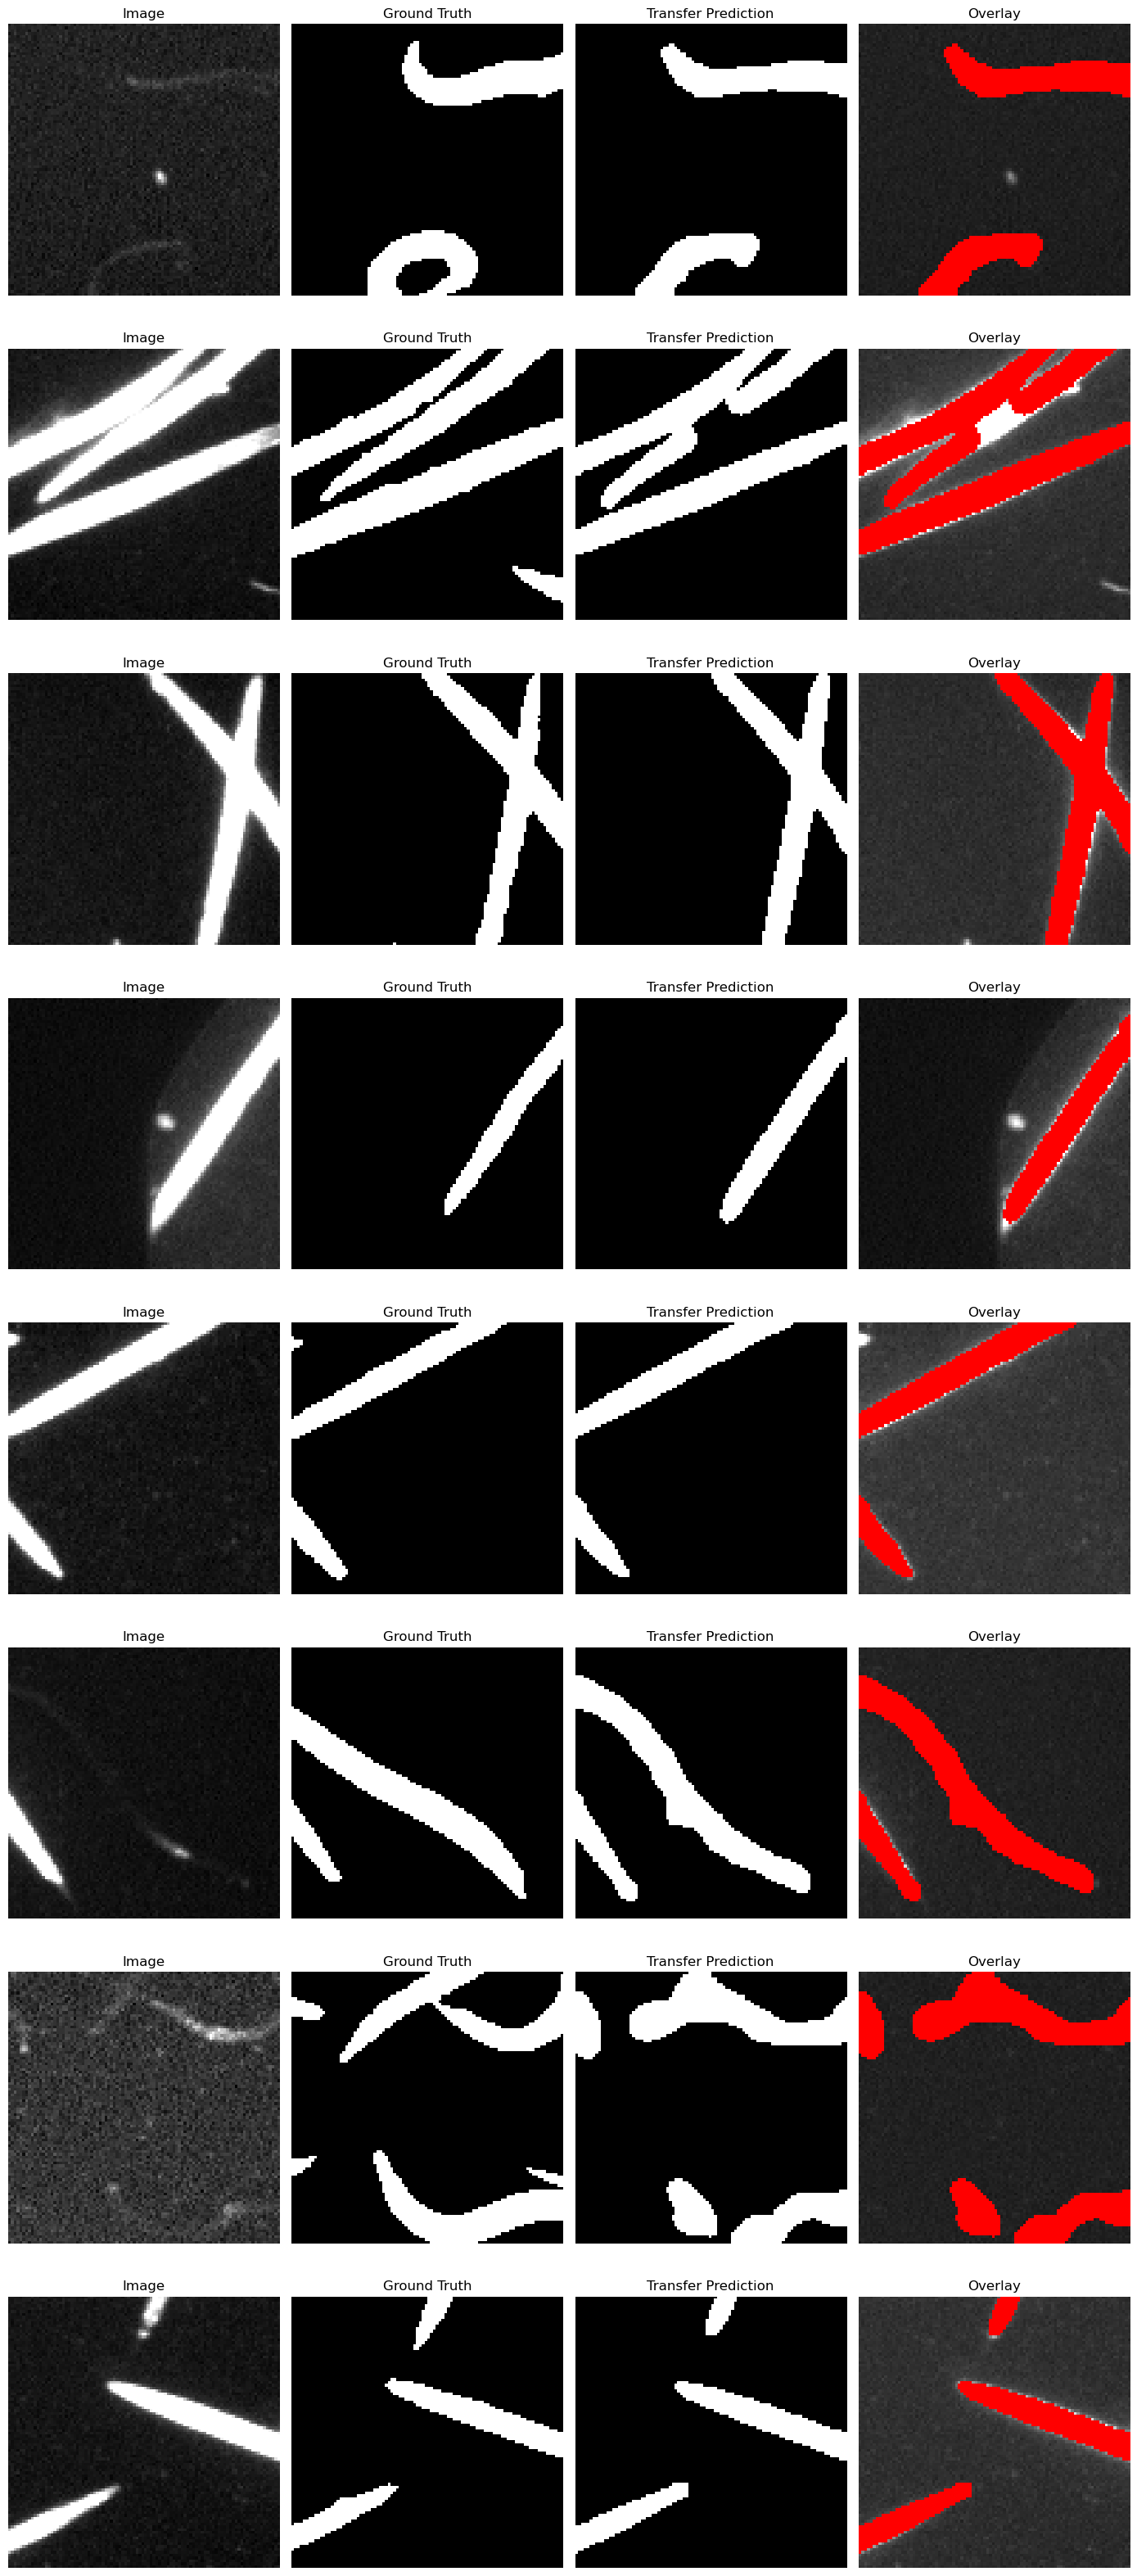

Saved final C. elegans prediction visualization to:
celegans_transfer_figures/step16_final_celegans_transfer_predictions.png


In [25]:
# ============================================================
# STEP 16: Visualize final C. elegans transfer predictions
# ============================================================
# This step visualizes the final best C. elegans model.
#
# Since Transfer learning and Transfer + SATLoss gave identical saved
# test results, we visualize the best transfer model.
#
# Columns:
#   Image | Ground Truth | Prediction | Overlay
# ============================================================

final_celegans_model.eval()

foreground_indices = [
    i for i, p in enumerate(test_patches)
    if p["foreground_ratio"] >= 0.05
]

num_samples = 8

selected_indices = random.sample(
    foreground_indices,
    min(num_samples, len(foreground_indices))
)

plt.figure(figsize=(14, 4 * len(selected_indices)))

for row, idx in enumerate(selected_indices):
    patch = test_patches[idx]

    image_patch = patch["image_patch"]
    mask_patch = patch["mask_patch"]

    image_tensor = torch.from_numpy(
        image_patch.astype(np.float32)
    ).unsqueeze(0).repeat(3, 1, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = final_celegans_model(image_tensor)
        probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()

    pred_np = pred[0, 0].cpu().numpy().astype(np.uint8)
    mask_np = mask_patch.astype(np.uint8)
    image_display = image_patch.astype(np.float32)

    overlay = np.stack(
        [image_display, image_display, image_display],
        axis=-1
    )
    overlay[pred_np == 1] = [1.0, 0.0, 0.0]

    plt.subplot(len(selected_indices), 4, 4 * row + 1)
    plt.imshow(image_display, cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Transfer Prediction")
    plt.axis("off")

    plt.subplot(len(selected_indices), 4, 4 * row + 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()

save_path = os.path.join(
    FIGURE_DIR,
    "step16_final_celegans_transfer_predictions.png"
)

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved final C. elegans prediction visualization to:")
print(save_path)